# Data Quality & Exploratory Data Analysis

This notebook assesses the quality and coverage of the collected data:
- **Tweets** scraped from X (Twitter) via Playwright
- **Price snapshots** (1-minute intraday) stored alongside tweets
- **Historical OHLCV prices** downloaded via yfinance

Goal: Identify data gaps, coverage issues, and basic statistics before sentiment analysis.

## 1 — Setup & Data Loading

In [92]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Global plot style: clean grid, muted colors, high resolution
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

# Paths to data sources
DATA_DIR = Path("..") / "data"
DB_PATH = DATA_DIR / "webmining.db"           # SQLite DB with tweets + snapshots
PRICES_CSV = DATA_DIR / "raw" / "prices" / "prices.csv"  # Historical OHLCV from yfinance

# Load all three SQLite tables into DataFrames
conn = sqlite3.connect(DB_PATH)

tweets = pd.read_sql("SELECT * FROM tweets", conn)            # Tweet metadata + content
snapshots = pd.read_sql("SELECT * FROM tweet_snapshots", conn) # Engagement snapshots (likes, RT)
price_snaps = pd.read_sql("SELECT * FROM price_snapshots", conn) # 1-min intraday prices per tweet

conn.close()

# Load the separately downloaded daily price history (CSV)
prices = pd.read_csv(PRICES_CSV)

# Convert date/time columns from strings to proper datetime objects
tweets["posted_at"] = pd.to_datetime(tweets["posted_at"])
price_snaps["timestamp"] = pd.to_datetime(price_snaps["timestamp"])
prices["Date"] = pd.to_datetime(prices["Date"])

# Quick sanity check: row counts for all data sources
print(f"Tweets:           {len(tweets):>6,}")
print(f"Tweet snapshots:  {len(snapshots):>6,}")
print(f"Price snapshots:  {len(price_snaps):>6,}")
print(f"Prices (CSV):     {len(prices):>6,}")

Tweets:            2,065
Tweet snapshots:   2,377
Price snapshots:  24,445
Prices (CSV):      3,927


## 2 — Tweet Data Overview

In [93]:
# High-level tweet statistics: how many have a stock symbol (cashtag)?
n_total = len(tweets)
n_with_symbol = tweets["symbol"].notna().sum()
n_without_symbol = n_total - n_with_symbol

print(f"Total tweets:       {n_total}")
print(f"With cashtag:       {n_with_symbol} ({n_with_symbol/n_total:.1%})")
print(f"Without cashtag:    {n_without_symbol} ({n_without_symbol/n_total:.1%})")
print(f"Unique symbols:     {tweets['symbol'].nunique()}")
print(f"Unique authors:     {tweets['author'].nunique()}")
print(f"Date range:         {tweets['posted_at'].min():%Y-%m-%d} → {tweets['posted_at'].max():%Y-%m-%d}")

Total tweets:       2065
With cashtag:       965 (46.7%)
Without cashtag:    1100 (53.3%)
Unique symbols:     101
Unique authors:     950
Date range:         2016-04-26 → 2026-04-23


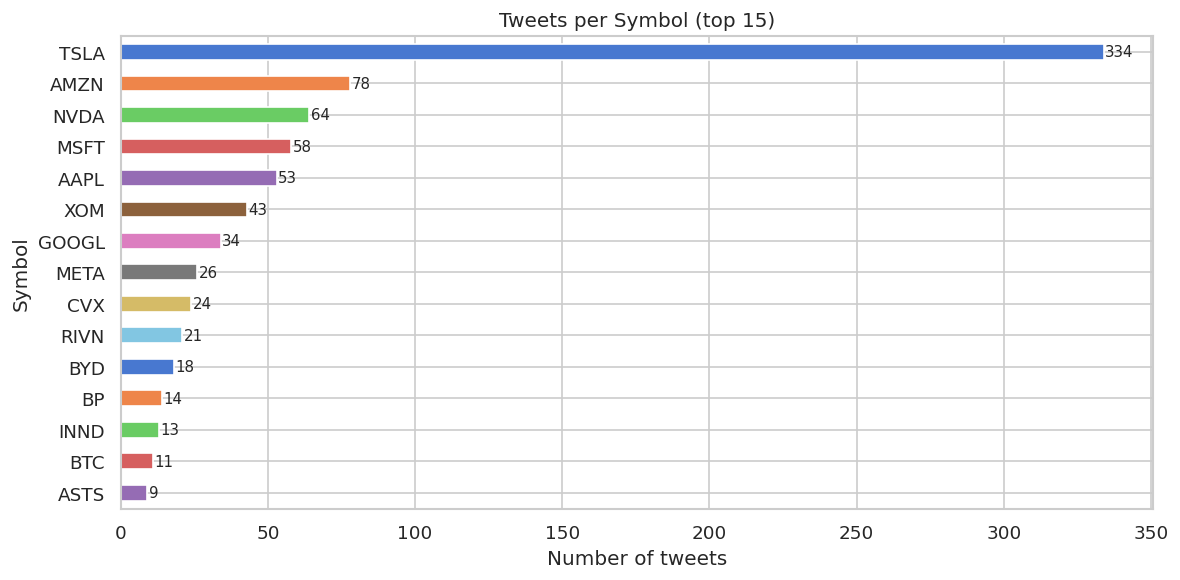

In [94]:
# Horizontal bar chart: which stock symbols appear most often?
# Shows the top 15 symbols by tweet count to identify data concentration.
symbol_counts = tweets["symbol"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
symbol_counts.plot.barh(ax=ax, color=sns.color_palette("muted", len(symbol_counts)))
ax.set_xlabel("Number of tweets")
ax.set_ylabel("Symbol")
ax.set_title("Tweets per Symbol (top 15)")
ax.invert_yaxis()
# Annotate each bar with its count
for i, v in enumerate(symbol_counts.values):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

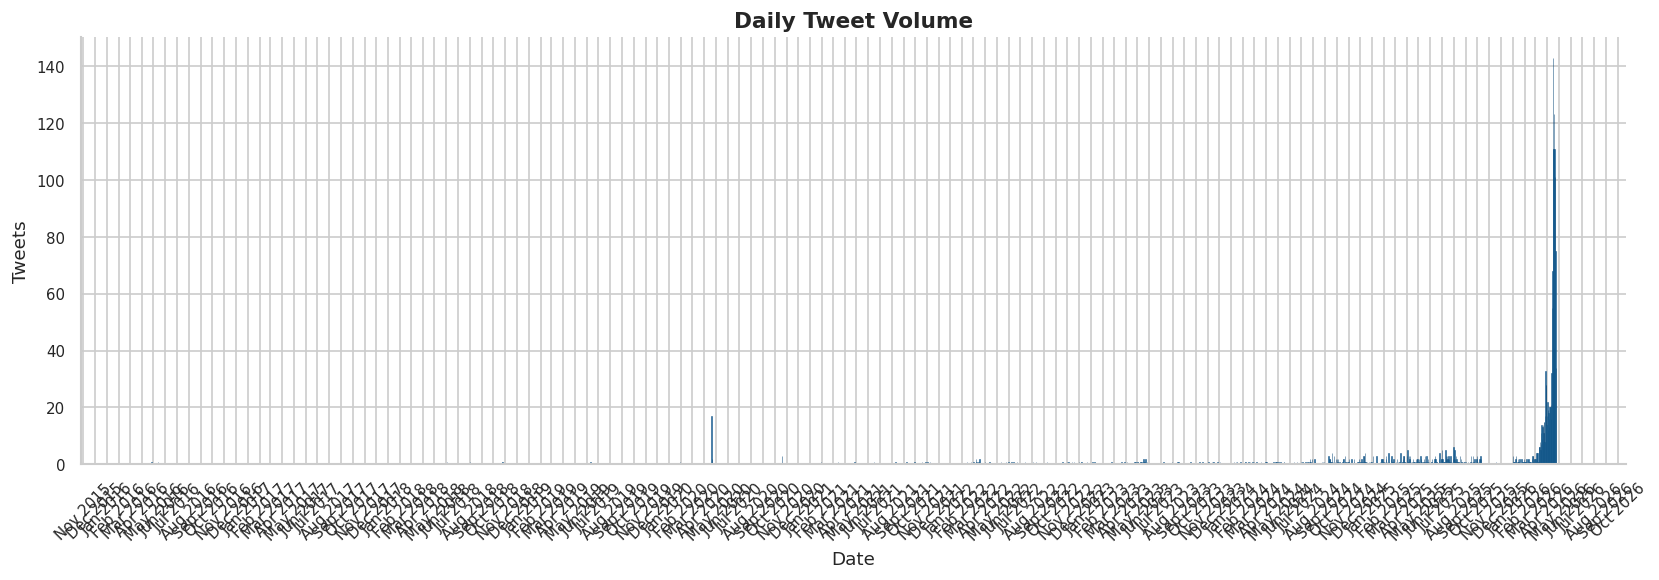

In [95]:
# Daily tweet volume over time — reveals collection gaps and activity spikes.
# Large gaps indicate crawler downtime or session expiry.
tweets["date"] = tweets["posted_at"].dt.date
daily_counts = tweets.groupby("date").size()

# Convert to datetime for proper x-axis formatting
daily_dates = pd.to_datetime(daily_counts.index)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(daily_dates, daily_counts.values, width=1.0, color="#1f77b4", edgecolor="#0d4a7a", linewidth=0.3)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Tweets", fontsize=11)
ax.set_title("Daily Tweet Volume", fontsize=13, fontweight="bold")

# Show one tick per month instead of every Monday — much more readable
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", labelsize=9)

# Remove top/right spines for cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [96]:
# Merge tweets with their engagement snapshots (likes, retweets)
# to get a combined view of author reach and post performance.
merged = tweets.merge(snapshots, on="tweet_id", how="left")

# Descriptive statistics for follower counts (author influence)
print("Follower count statistics:")
print(tweets["author_followers"].describe().to_string())
print()
# Descriptive statistics for engagement metrics
print("Engagement statistics (likes / retweets):")
print(merged[["likes", "retweets"]].describe().to_string())

Follower count statistics:
count    2.065000e+03
mean     2.874439e+05
std      9.606245e+05
min      1.000000e+02
25%      1.350000e+04
50%      5.230000e+04
75%      2.239000e+05
max      1.390000e+07

Engagement statistics (likes / retweets):
              likes      retweets
count   2377.000000   2377.000000
mean     491.484224     87.504838
std     1170.812091    379.276210
min        0.000000      0.000000
25%      132.000000     11.000000
50%      210.000000     27.000000
75%      523.000000     68.000000
max    33000.000000  13000.000000


### 2.1 — Duplicate & Empty Text Check

In [97]:
# Data quality check: detect duplicate and empty tweets.
# - Duplicate tweet_ids would indicate a crawler bug (same tweet stored twice).
# - Duplicate content may be bots or copy-paste posts.
# - Empty content means the text couldn't be extracted.
n_dup_id = tweets['tweet_id'].duplicated().sum()
n_dup_content = tweets['content'].duplicated().sum()
n_empty = tweets['content'].isna().sum() + (tweets['content'].str.strip() == '').sum()

print(f"Duplicate tweet_ids:    {n_dup_id}")
print(f"Duplicate content:      {n_dup_content}")
print(f"Empty / NaN content:    {n_empty}")

# If duplicates exist, show the most frequently repeated text
if n_dup_content > 0:
    print(f"\nMost repeated content (top 5):")
    dup_content = tweets[tweets['content'].duplicated(keep=False)]
    print(dup_content['content'].value_counts().head(5).to_string())

Duplicate tweet_ids:    0
Duplicate content:      8
Empty / NaN content:    0

Most repeated content (top 5):
content
From insights to impact: Play Chapter 2 and grab your vouchers!\nYour insights can earn you ₹1000 vouchers!\n\nRules to play:\nFollow \n@TPIndiaOfficial\n\nLike & share all posts\nHashtags: #TPDataTrivia #AI #TPIndia\nTag \n@tpindiaofficial\n + 3 buddies\nMultiple unique answers welcome!    3
„So grün, dass sie fast pleite gegangen wären“: US-Präsident Donald Trump schießt gegen Deutschland. #USA #Kohleabbau #Energie                                                                                                                                                                      2
Tomorrow morning I’m loading up $200,000 in call options on a single ticker.\n\nMy biggest play since $GME $OPEN $TSLA $NVDA $AMD \n\nMark my words 99% of traders will miss this next $OPEN type mover. I WILL NOT and my my followers won’t either.\n\nI’m only sending this ticker to those      2


### 2.2 — Language Detection

Detected languages (21 total):
lang
en    1974
de      40
af       9
nl       6
sv       5
da       4
tl       4
ro       3
no       3
ca       3

English share: 95.6%


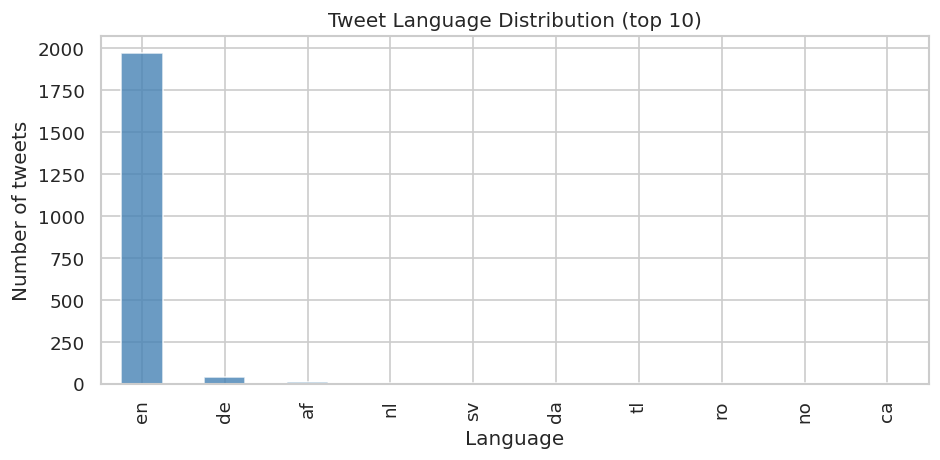

In [98]:
# Detect the language of each tweet using the langdetect library.
# Important for filtering: sentiment models typically expect English text.
# A high non-English share would require multilingual models or filtering.
from langdetect import detect, LangDetectException
from langdetect import DetectorFactory
DetectorFactory.seed = 42  # Fixed seed for reproducible language detection

def safe_detect(text: str) -> str:
    """Detect language, return 'unknown' on failure (e.g. NaN, very short text)."""
    try:
        return detect(text)
    except (LangDetectException, TypeError):
        return "unknown"

# Apply language detection to every tweet
tweets["lang"] = tweets["content"].apply(safe_detect)

# Show distribution of detected languages
lang_counts = tweets["lang"].value_counts()
print(f"Detected languages ({len(lang_counts)} total):")
print(lang_counts.head(10).to_string())
print(f"\nEnglish share: {(tweets['lang'] == 'en').mean():.1%}")

# Bar chart of top 10 languages
fig, ax = plt.subplots(figsize=(8, 4))
lang_counts.head(10).plot.bar(ax=ax, color="steelblue", alpha=0.8)
ax.set_xlabel("Language")
ax.set_ylabel("Number of tweets")
ax.set_title("Tweet Language Distribution (top 10)")
plt.tight_layout()
plt.show()

### 2.3 — Engagement Distribution: Viral vs. Normal

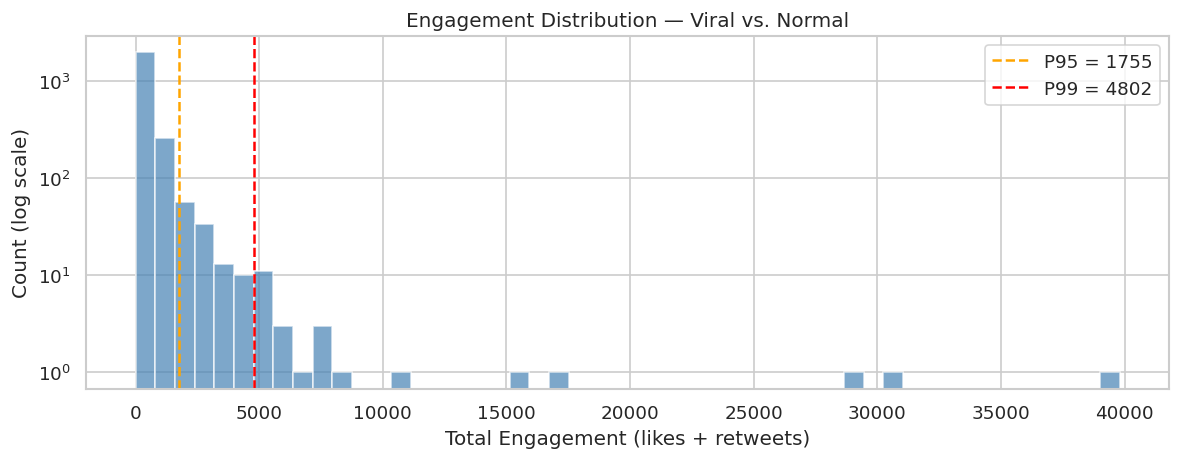

Viral threshold (P95): 1755
Viral tweets (≥P95):   119 (5.0%)
P99 threshold:         4802


In [99]:
# Analyze the engagement distribution to separate "viral" from "normal" tweets.
# Total engagement = likes + retweets. A small fraction of tweets drives most engagement.
# We use P95 as the viral threshold and P99 for extreme outliers.
merged["total_engagement"] = merged["likes"].fillna(0) + merged["retweets"].fillna(0)

p95 = merged["total_engagement"].quantile(0.95)
p99 = merged["total_engagement"].quantile(0.99)

# Histogram with log-scale y-axis (engagement is heavily right-skewed)
fig, ax = plt.subplots(figsize=(10, 4))
merged["total_engagement"].clip(lower=0).hist(
    bins=50, ax=ax, color="steelblue", alpha=0.7, log=True
)
# Mark the P95 and P99 thresholds as vertical lines
ax.axvline(p95, color="orange", linestyle="--", linewidth=1.5, label=f"P95 = {p95:.0f}")
ax.axvline(p99, color="red", linestyle="--", linewidth=1.5, label=f"P99 = {p99:.0f}")
ax.set_xlabel("Total Engagement (likes + retweets)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Engagement Distribution — Viral vs. Normal")
ax.legend()
plt.tight_layout()
plt.show()

# Summary numbers
n_viral = (merged["total_engagement"] >= p95).sum()
print(f"Viral threshold (P95): {p95:.0f}")
print(f"Viral tweets (≥P95):   {n_viral} ({n_viral/len(merged):.1%})")
print(f"P99 threshold:         {p99:.0f}")

## 3 — Price Snapshot Coverage

In [100]:
# Check how many tweets have associated 1-minute intraday price snapshots.
# These snapshots were fetched during crawling to capture price movement around each tweet.
# Missing price data = tweet was posted outside market hours or the fetcher failed.
tweet_ids_with_prices = price_snaps["tweet_id"].unique()
n_with_prices = tweets["tweet_id"].isin(tweet_ids_with_prices).sum()
n_without_prices = len(tweets) - n_with_prices

print(f"Tweets with price data:    {n_with_prices} ({n_with_prices/len(tweets):.1%})")
print(f"Tweets without price data: {n_without_prices} ({n_without_prices/len(tweets):.1%})")
print(f"Average price snapshots per tweet (where available): "
      f"{price_snaps.groupby('tweet_id').size().mean():.1f}")
print(f"Total price snapshot rows: {len(price_snaps):,}")

Tweets with price data:    244 (11.8%)
Tweets without price data: 1821 (88.2%)
Average price snapshots per tweet (where available): 100.2
Total price snapshot rows: 24,445


In [101]:
# Price snapshot coverage broken down by stock symbol.
# Shows which tickers have the best/worst price data coverage.
# Low coverage means many tweets for that symbol lack price context.
tweets_with_price_flag = tweets.copy()
tweets_with_price_flag["has_price"] = tweets["tweet_id"].isin(tweet_ids_with_prices)
coverage = (
    tweets_with_price_flag[tweets_with_price_flag["symbol"].notna()]
    .groupby("symbol")["has_price"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "with_price", "count": "total"})
    .assign(pct=lambda d: d["with_price"] / d["total"])
    .sort_values("total", ascending=False)
    .head(15)
)
print(coverage.to_string())

        with_price  total       pct
symbol                             
TSLA           100    334  0.299401
AMZN            20     78  0.256410
NVDA             9     64  0.140625
MSFT            19     58  0.327586
AAPL            10     53  0.188679
XOM              8     43  0.186047
GOOGL           20     34  0.588235
META             8     26  0.307692
CVX              2     24  0.083333
RIVN             0     21  0.000000
BYD              0     18  0.000000
BP               5     14  0.357143
INND             0     13  0.000000
BTC              2     11  0.181818
ASTS             4      9  0.444444


## 4 — Historical Price Data (CSV) Quality

In [102]:
# Overview of the historical daily price CSV downloaded via yfinance.
# Check for: total rows, tickers present, date range, and missing values (NaNs).
print(f"Rows: {len(prices):,}")
print(f"Tickers: {sorted(prices['Ticker'].unique())}")
print(f"Date range: {prices['Date'].min():%Y-%m-%d} → {prices['Date'].max():%Y-%m-%d}")
print(f"Missing values:\n{prices.isnull().sum().to_string()}")
print()

# How many rows per ticker? Unequal counts may indicate partial downloads.
rows_per_ticker = prices.groupby("Ticker").agg(
    rows=("Date", "count"),
    first_date=("Date", "min"),
    last_date=("Date", "max"),
)
print("Rows per ticker:")
print(rows_per_ticker.to_string())

Rows: 3,927
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
Date range: 2024-01-02 → 2026-03-27
Missing values:
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0

Rows per ticker:
        rows first_date  last_date
Ticker                            
AAPL     561 2024-01-02 2026-03-27
AMZN     561 2024-01-02 2026-03-27
GOOGL    561 2024-01-02 2026-03-27
META     561 2024-01-02 2026-03-27
MSFT     561 2024-01-02 2026-03-27
NVDA     561 2024-01-02 2026-03-27
TSLA     561 2024-01-02 2026-03-27


In [103]:
# Descriptive statistics (mean, std, min, max, quartiles) of Adjusted Close per ticker.
# Helps spot obviously wrong values (e.g. price = 0, extreme outliers).
price_stats = prices.groupby("Ticker")["Adj Close"].describe()
print(price_stats.to_string())

        count        mean         std         min         25%         50%         75%         max
Ticker                                                                                           
AAPL    561.0  222.963505   30.520590  163.511917  200.390213  224.415833  246.612839  285.922455
AMZN    561.0  203.147986   23.924227  144.570007  183.630005  205.020004  223.809998  254.000000
GOOGL   561.0  199.968445   58.126495  130.322876  161.795700  175.055496  233.722473  343.448242
META    561.0  592.671304  100.552432  341.787842  506.148682  596.150208  665.460022  788.148987
MSFT    561.0  436.221114   44.186263  351.866211  404.256165  420.758728  475.279053  539.825256
NVDA    561.0  136.326184   38.290048   47.539940  110.903862  134.756561  176.950562  207.017273
TSLA    561.0  306.167201   97.067872  142.050003  218.850006  309.260010  400.989990  489.880005


### 4.1 — Missing Trading Days

In [104]:
# Compare the dates in our CSV against the official NYSE trading calendar.
# Missing trading days = days when the market was open but we have no price data.
# Uses the exchange_calendars library for accurate holiday/half-day handling.
import exchange_calendars as xcals

tickers = sorted(prices["Ticker"].unique())

# Get all NYSE trading sessions in the date range of our price data
xnys = xcals.get_calendar("XNYS")
price_start = prices["Date"].min()
price_end = prices["Date"].max()
trading_days = xnys.sessions_in_range(price_start, price_end)

print(f"NYSE trading days in range: {len(trading_days)}")

# For each ticker, find which expected trading days are missing from the CSV
missing_per_ticker = {}
for ticker in tickers:
    ticker_dates = set(prices[prices['Ticker'] == ticker]['Date'].dt.normalize())
    missing = sorted(set(trading_days) - ticker_dates)
    missing_per_ticker[ticker] = missing

# Summary table: expected vs. actual trading day count per ticker
missing_df = pd.DataFrame([
    {"Ticker": t, "expected": len(trading_days), "present": len(trading_days) - len(m),
     "missing": len(m), "pct_complete": (len(trading_days) - len(m)) / len(trading_days)}
    for t, m in missing_per_ticker.items()
])
print("\nTrading day completeness per ticker:")
print(missing_df.to_string(index=False))

# Preview the first few missing dates per ticker (if any)
for t, m in missing_per_ticker.items():
    if m:
        preview = [d.strftime('%Y-%m-%d') for d in m[:5]]
        suffix = f' ... (+{len(m)-5} more)' if len(m) > 5 else ''
        print(f"  {t} missing: {', '.join(preview)}{suffix}")

NYSE trading days in range: 561

Trading day completeness per ticker:
Ticker  expected  present  missing  pct_complete
  AAPL       561      561        0           1.0
  AMZN       561      561        0           1.0
 GOOGL       561      561        0           1.0
  META       561      561        0           1.0
  MSFT       561      561        0           1.0
  NVDA       561      561        0           1.0
  TSLA       561      561        0           1.0


### 4.2 — Daily Returns & Outlier Detection

Outlier returns (IQR×3): 38 of 3920

Largest negative returns:
      Date Ticker  Adj Close  return_pct
2025-01-27   NVDA 118.381210  -16.968170
2025-03-10   TSLA 222.149994  -15.426207
2025-10-30   META 665.357239  -11.334753
2024-04-25   META 438.407928  -10.561291
2026-01-29   MSFT 432.512817   -9.993146

Largest positive returns:
      Date Ticker  Adj Close  return_pct
2024-02-22   NVDA  78.490028   16.400880
2025-04-09   NVDA 114.303070   18.722746
2024-02-02   META 471.291534   20.317644
2024-10-24   TSLA 260.480011   21.919035
2025-04-09   TSLA 272.200012   22.689990


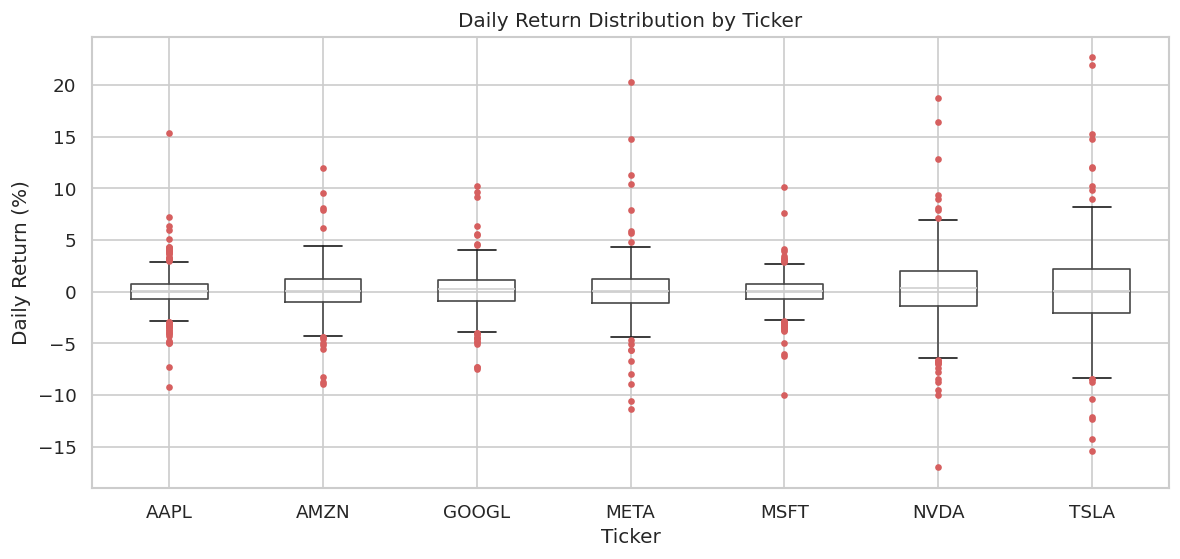

In [105]:
# Calculate daily percentage returns and flag statistical outliers.
# Returns = (price_today / price_yesterday - 1) × 100
# Outlier detection uses IQR × 3 per ticker (conservative threshold).
prices_sorted = prices.sort_values(["Ticker", "Date"])
prices_sorted["return_pct"] = (
    prices_sorted.groupby("Ticker")["Adj Close"].pct_change() * 100
)

# IQR-based outlier detection: values beyond Q1 - 3*IQR or Q3 + 3*IQR
# Using transform() to avoid index alignment issues with groupby().apply()
def iqr_outlier(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - 3 * iqr) | (s > q3 + 3 * iqr)

prices_sorted["is_outlier"] = prices_sorted.groupby("Ticker")["return_pct"].transform(iqr_outlier)

n_outliers = prices_sorted["is_outlier"].sum()
print(f"Outlier returns (IQR×3): {n_outliers} of {prices_sorted['return_pct'].notna().sum()}")

# Show the most extreme returns (potential data errors or real market events)
if n_outliers > 0:
    outlier_rows = prices_sorted[prices_sorted["is_outlier"]].sort_values("return_pct")
    print("\nLargest negative returns:")
    print(outlier_rows[["Date", "Ticker", "Adj Close", "return_pct"]].head(5).to_string(index=False))
    print("\nLargest positive returns:")
    print(outlier_rows[["Date", "Ticker", "Adj Close", "return_pct"]].tail(5).to_string(index=False))

# Boxplot comparing daily return distributions across tickers
fig, ax = plt.subplots(figsize=(10, 5))
prices_sorted.boxplot(column="return_pct", by="Ticker", ax=ax, sym="r.")
ax.set_title("Daily Return Distribution by Ticker")
ax.set_xlabel("Ticker")
ax.set_ylabel("Daily Return (%)")
plt.suptitle("")
plt.tight_layout()
plt.show()

### 4.3 — Returns & Rolling Volatility

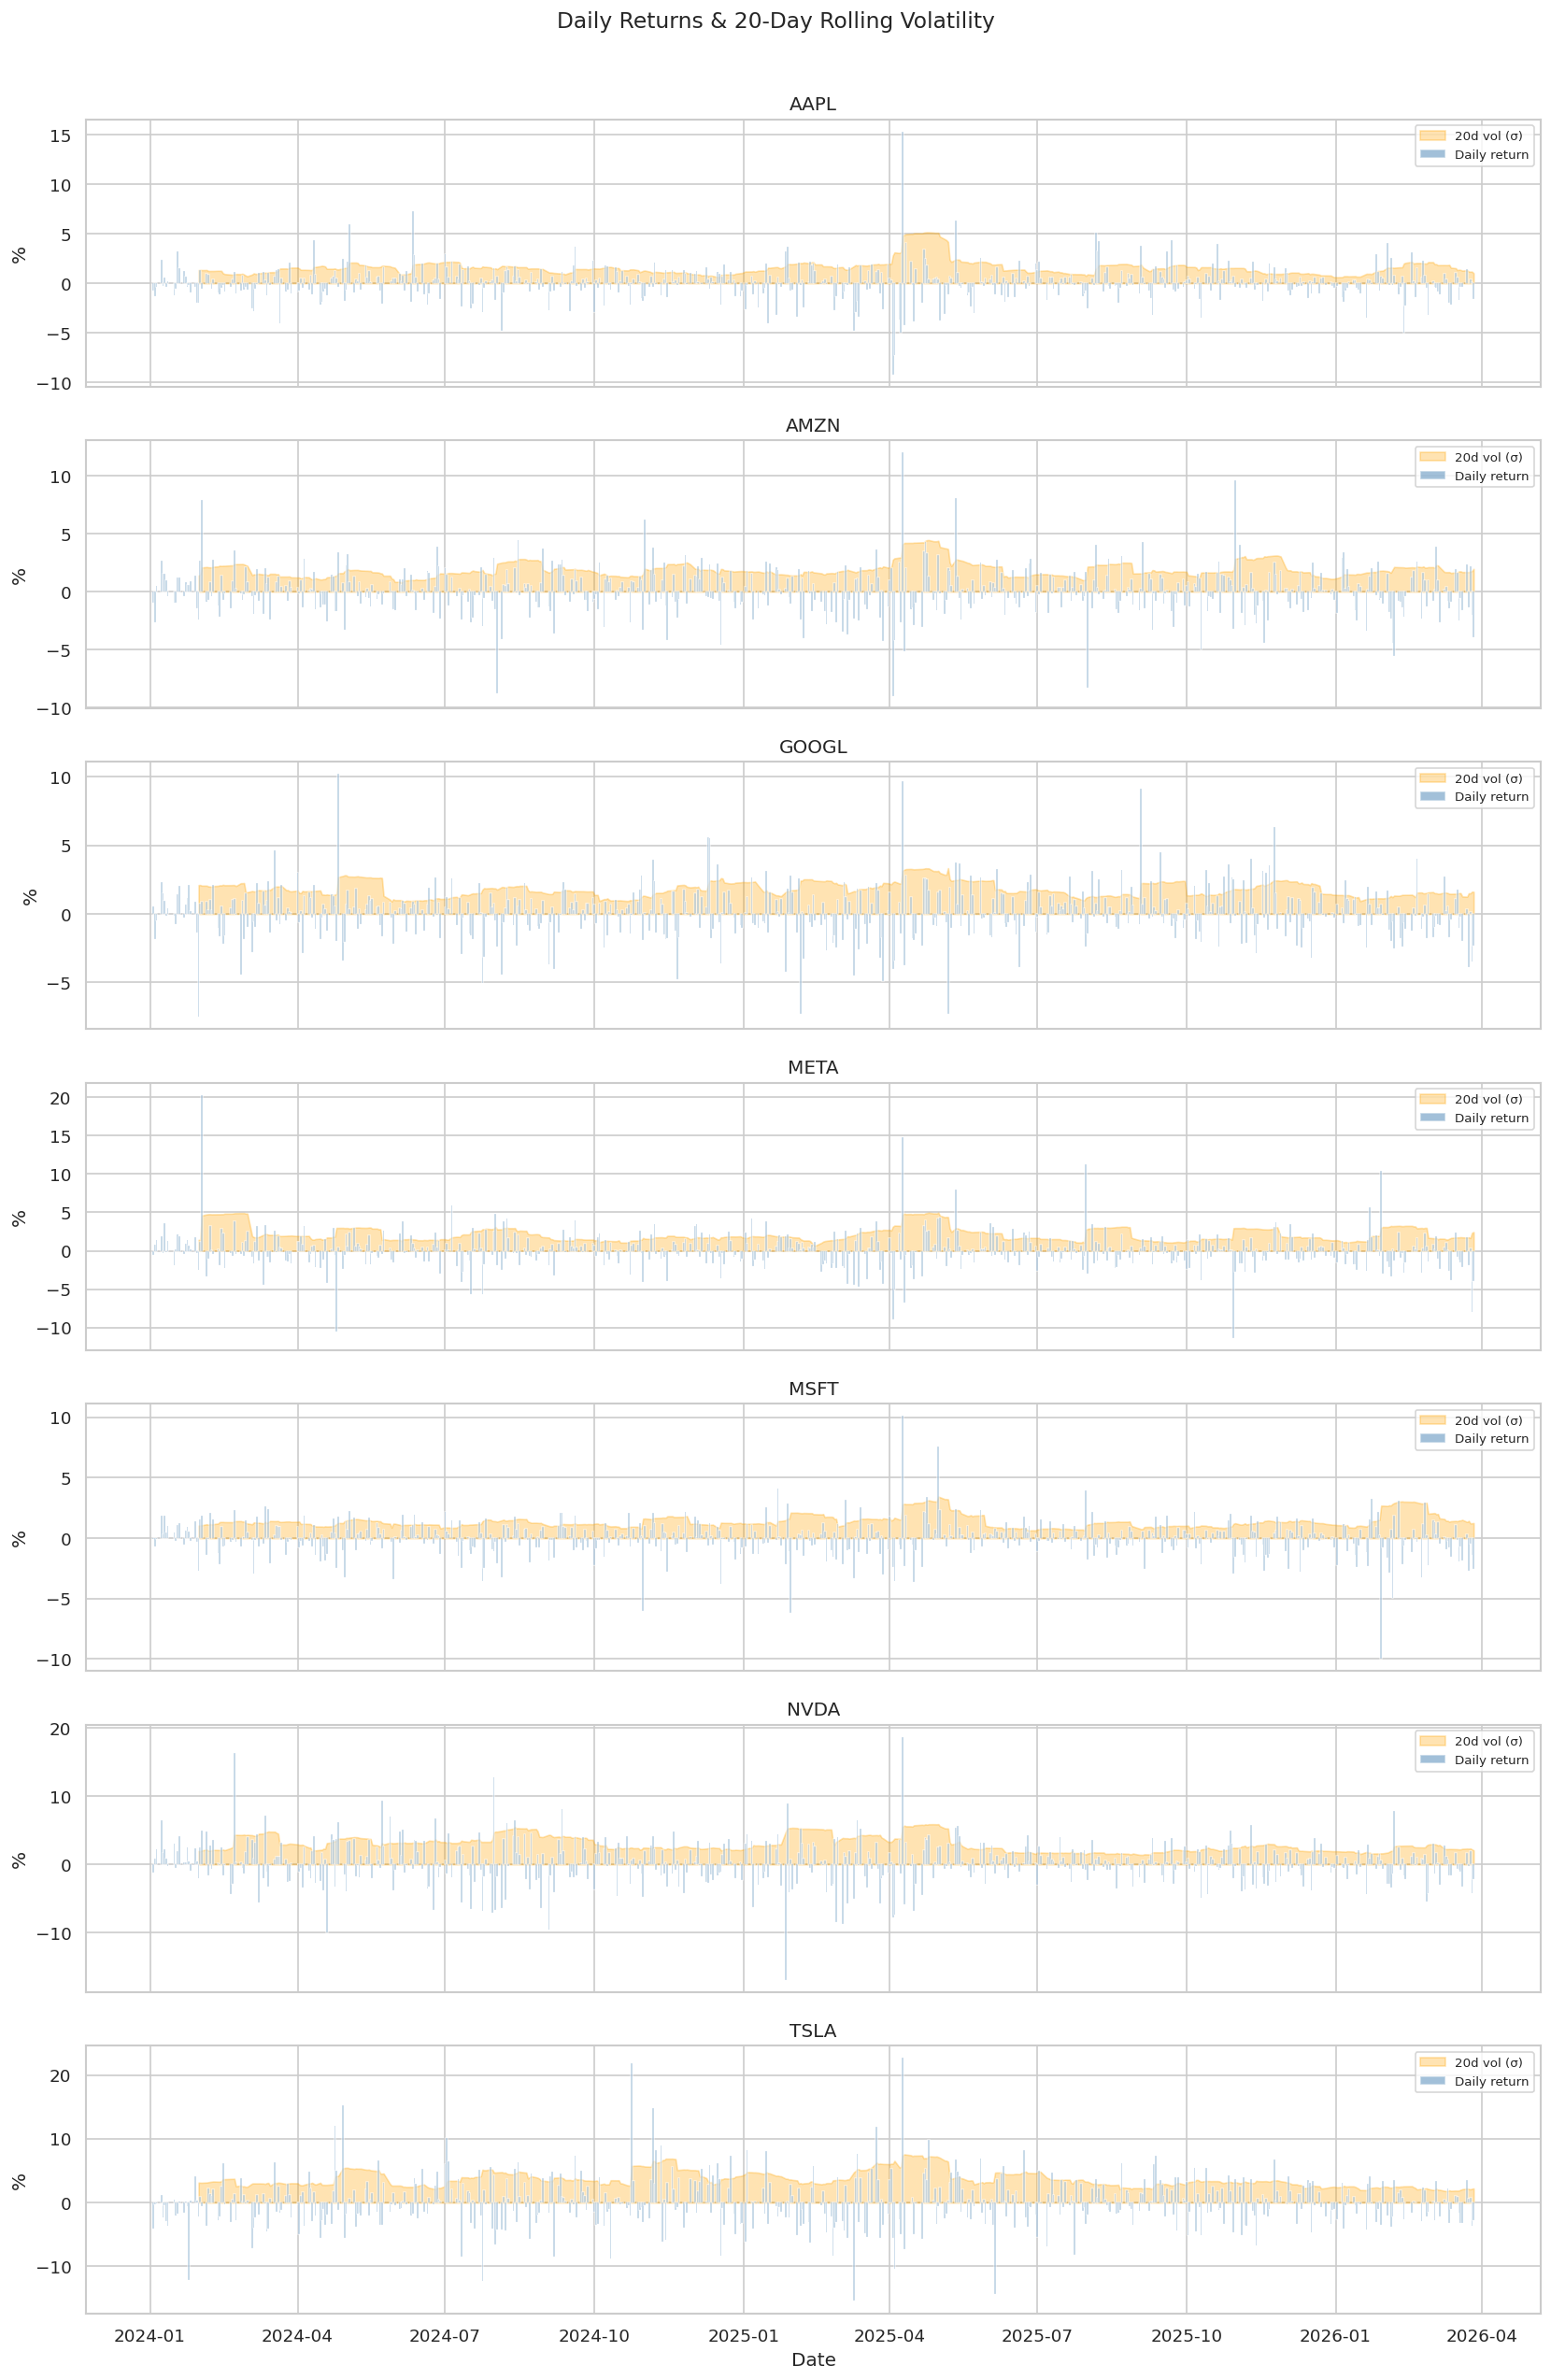

In [106]:
# Plot daily returns (bars) overlaid with 20-day rolling volatility (filled area).
# Rolling volatility = standard deviation of returns over the last 20 trading days.
# High volatility periods may correlate with increased social media activity.
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 3 * len(tickers)), sharex=True)
if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    subset = prices_sorted[prices_sorted["Ticker"] == ticker].sort_values("Date")
    vol_20d = subset["return_pct"].rolling(20).std()

    ax.fill_between(subset["Date"], vol_20d, alpha=0.3, color="orange", label="20d vol (σ)")
    ax.bar(subset["Date"], subset["return_pct"], width=1, alpha=0.5, color="steelblue", label="Daily return")
    ax.set_ylabel("%")
    ax.set_title(ticker)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Date")
fig.suptitle("Daily Returns & 20-Day Rolling Volatility", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4.5 — Cross-Source Alignment: Tweets ↔ Prices

In [107]:
# Compare tweet and price date ranges to find the overlapping period.
# Only tweets within the overlap can be matched to daily price data.
# Handles timezone-aware tweet timestamps vs. timezone-naive price dates.
tweet_min = tweets["posted_at"].min()
tweet_max = tweets["posted_at"].max()
price_min = prices["Date"].min()
price_max = prices["Date"].max()

# Strip timezone info for comparison (tweets are UTC, prices are tz-naive)
tweet_min_naive = tweet_min.tz_localize(None) if tweet_min.tzinfo else tweet_min
tweet_max_naive = tweet_max.tz_localize(None) if tweet_max.tzinfo else tweet_max

overlap_start = max(tweet_min_naive, price_min)
overlap_end = min(tweet_max_naive, price_max)

print(f"Tweet range:   {tweet_min_naive:%Y-%m-%d} → {tweet_max_naive:%Y-%m-%d}")
print(f"Price range:   {price_min:%Y-%m-%d} → {price_max:%Y-%m-%d}")
print(f"Overlap:       {overlap_start:%Y-%m-%d} → {overlap_end:%Y-%m-%d}")
print(f"Overlap days:  {(overlap_end - overlap_start).days}")

# Count how many tweets fall within the overlap period
tweets_posted_naive = tweets["posted_at"].dt.tz_localize(None) if tweets["posted_at"].dt.tz else tweets["posted_at"]
tweets_in_overlap = tweets[
    (tweets_posted_naive >= overlap_start) & (tweets_posted_naive <= overlap_end)
]
print(f"Tweets within overlap: {len(tweets_in_overlap)} of {len(tweets)} ({len(tweets_in_overlap)/len(tweets):.1%})")

Tweet range:   2016-04-26 → 2026-04-23
Price range:   2024-01-02 → 2026-03-27
Overlap:       2024-01-02 → 2026-03-27
Overlap days:  815
Tweets within overlap: 636 of 2065 (30.8%)


### 4.5b — Tweets on Non-Trading Days

In [108]:
# Identify tweets posted on non-trading days (weekends, NYSE holidays).
# These tweets can't be directly matched to same-day price movements.
# Strategy needed: map to next trading day, or analyze separately.
tweet_dates_norm = tweets["posted_at"].dt.tz_localize(None).dt.normalize() if tweets["posted_at"].dt.tz else tweets["posted_at"].dt.normalize()
trading_days_set = set(trading_days)

# Flag each tweet as trading day or non-trading day
tweets["is_trading_day"] = tweet_dates_norm.isin(trading_days_set)
tweets["day_of_week"] = tweets["posted_at"].dt.day_name()

n_trading = tweets["is_trading_day"].sum()
n_non_trading = (~tweets["is_trading_day"]).sum()

print(f"Tweets on trading days:      {n_trading} ({n_trading/len(tweets):.1%})")
print(f"Tweets on non-trading days:  {n_non_trading} ({n_non_trading/len(tweets):.1%})")
print()
# Break down non-trading tweets by weekday to distinguish weekends from holidays
print("Non-trading day breakdown by weekday:")
non_td = tweets[~tweets["is_trading_day"]]
print(non_td["day_of_week"].value_counts().to_string())

Tweets on trading days:      522 (25.3%)
Tweets on non-trading days:  1543 (74.7%)

Non-trading day breakdown by weekday:
day_of_week
Sunday       270
Wednesday    247
Thursday     242
Tuesday      229
Monday       227
Saturday     175
Friday       153


### 4.5c — Exploratory Lag Analysis: Tweet Volume → Next-Day Return

/home/ilker/repos/WebMiningProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ilker/repos/WebMiningProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


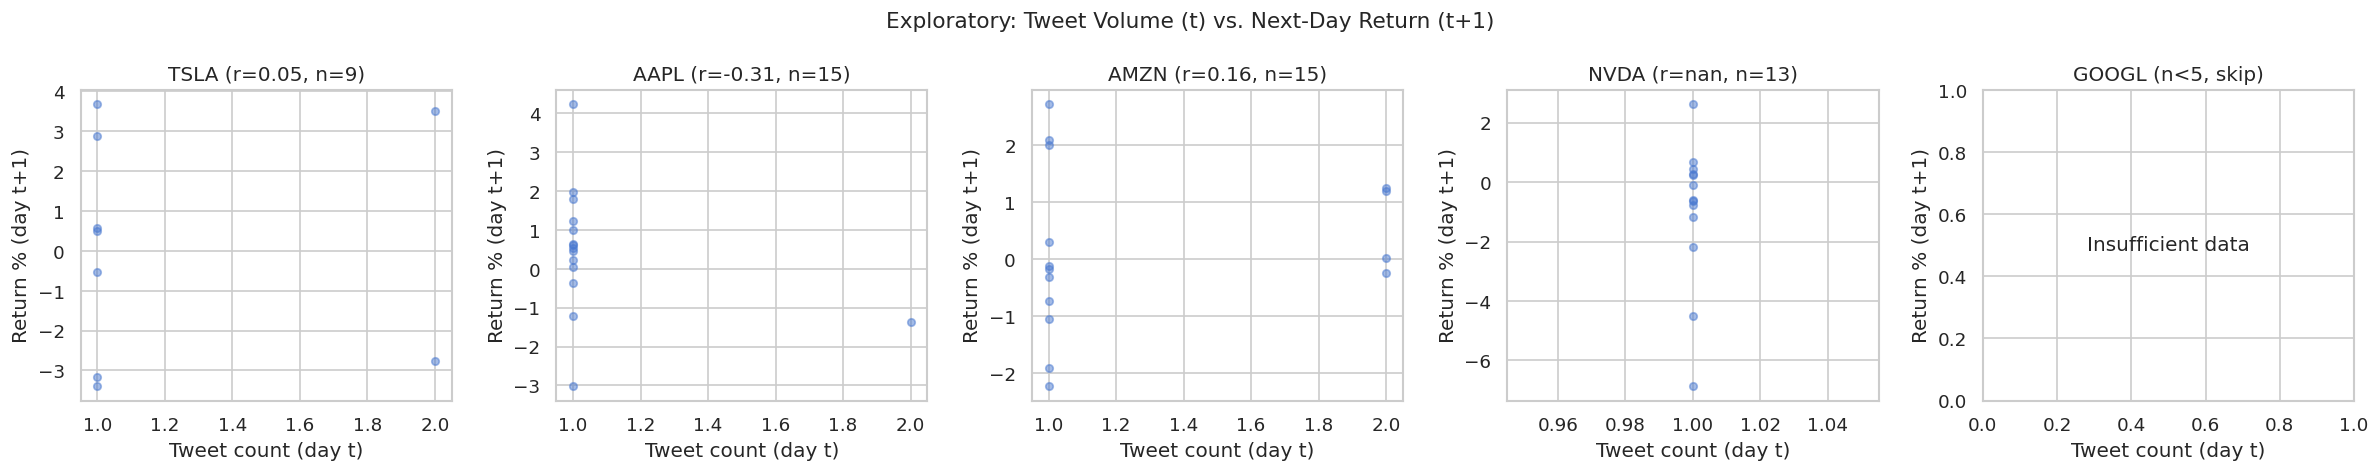

In [109]:
# Exploratory lag analysis: does tweet volume on day t correlate with
# the stock return on day t+1? This is a first look at predictive signal.
# Scatter plots with Pearson correlation for each top ticker.
target_tickers = ["TSLA", "AAPL", "AMZN", "NVDA", "GOOGL"]
target_tickers = [t for t in target_tickers if t in tweets["symbol"].values]

fig, axes = plt.subplots(1, len(target_tickers), figsize=(4 * len(target_tickers), 4))
if len(target_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, target_tickers):
    # Count tweets per day for this ticker
    tw = tweets[tweets["symbol"] == ticker].copy()
    tw_daily = tw.groupby(tw["posted_at"].dt.tz_localize(None).dt.normalize() if tw["posted_at"].dt.tz else tw["posted_at"].dt.normalize()).size().rename("tweet_count")

    # Get daily returns for this ticker
    ret = prices_sorted[prices_sorted["Ticker"] == ticker][["Date", "return_pct"]].copy()
    ret["Date"] = ret["Date"].dt.normalize()
    ret = ret.set_index("Date")["return_pct"]

    # Align: tweet volume on day t → return on day t+1 (shift returns back by 1)
    combined = pd.DataFrame({"tweet_count": tw_daily, "return_t1": ret.shift(-1)}).dropna()

    if len(combined) >= 5:
        ax.scatter(combined["tweet_count"], combined["return_t1"], alpha=0.5, s=20)
        corr = combined["tweet_count"].corr(combined["return_t1"])
        ax.set_title(f"{ticker} (r={corr:.2f}, n={len(combined)})")
    else:
        ax.set_title(f"{ticker} (n<5, skip)")
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center", transform=ax.transAxes)

    ax.set_xlabel("Tweet count (day t)")
    ax.set_ylabel("Return % (day t+1)")

fig.suptitle("Exploratory: Tweet Volume (t) vs. Next-Day Return (t+1)", fontsize=13)
plt.tight_layout()
plt.show()

## 5 — Coverage Matrix: Tweets with Price Data by Ticker × Week

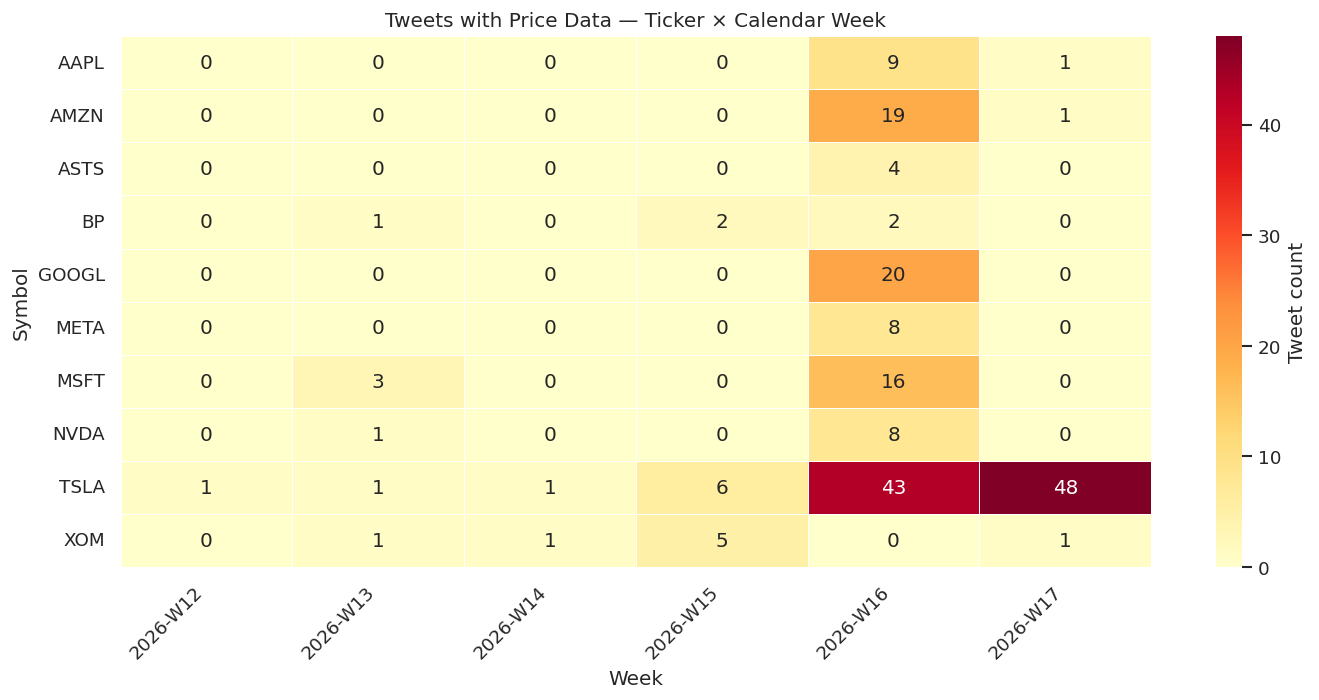

In [110]:
# Heatmap: tweets with price data, broken down by ticker × calendar week.
# Reveals temporal coverage patterns — which tickers have data in which weeks?
# Empty cells = no tweets with price snapshots for that ticker/week combination.
df_cov = tweets_with_price_flag[
    tweets_with_price_flag["symbol"].notna() & tweets_with_price_flag["has_price"]
].copy()
df_cov["week"] = df_cov["posted_at"].dt.isocalendar().week.astype(int)
df_cov["year_week"] = (
    df_cov["posted_at"].dt.isocalendar().year.astype(str)
    + "-W"
    + df_cov["week"].astype(str).str.zfill(2)
)

# Focus on top 10 symbols by tweet count
top_symbols = df_cov["symbol"].value_counts().head(10).index.tolist()
df_cov_top = df_cov[df_cov["symbol"].isin(top_symbols)]

# Pivot table: rows = symbols, columns = calendar weeks, values = tweet count
pivot = df_cov_top.pivot_table(
    index="symbol", columns="year_week", values="tweet_id", aggfunc="count", fill_value=0
)

fig, ax = plt.subplots(figsize=(max(12, len(pivot.columns) * 0.6), 6))
sns.heatmap(
    pivot,
    annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Tweet count"}
)
ax.set_title("Tweets with Price Data — Ticker × Calendar Week")
ax.set_ylabel("Symbol")
ax.set_xlabel("Week")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6 — Historical Price Time Series

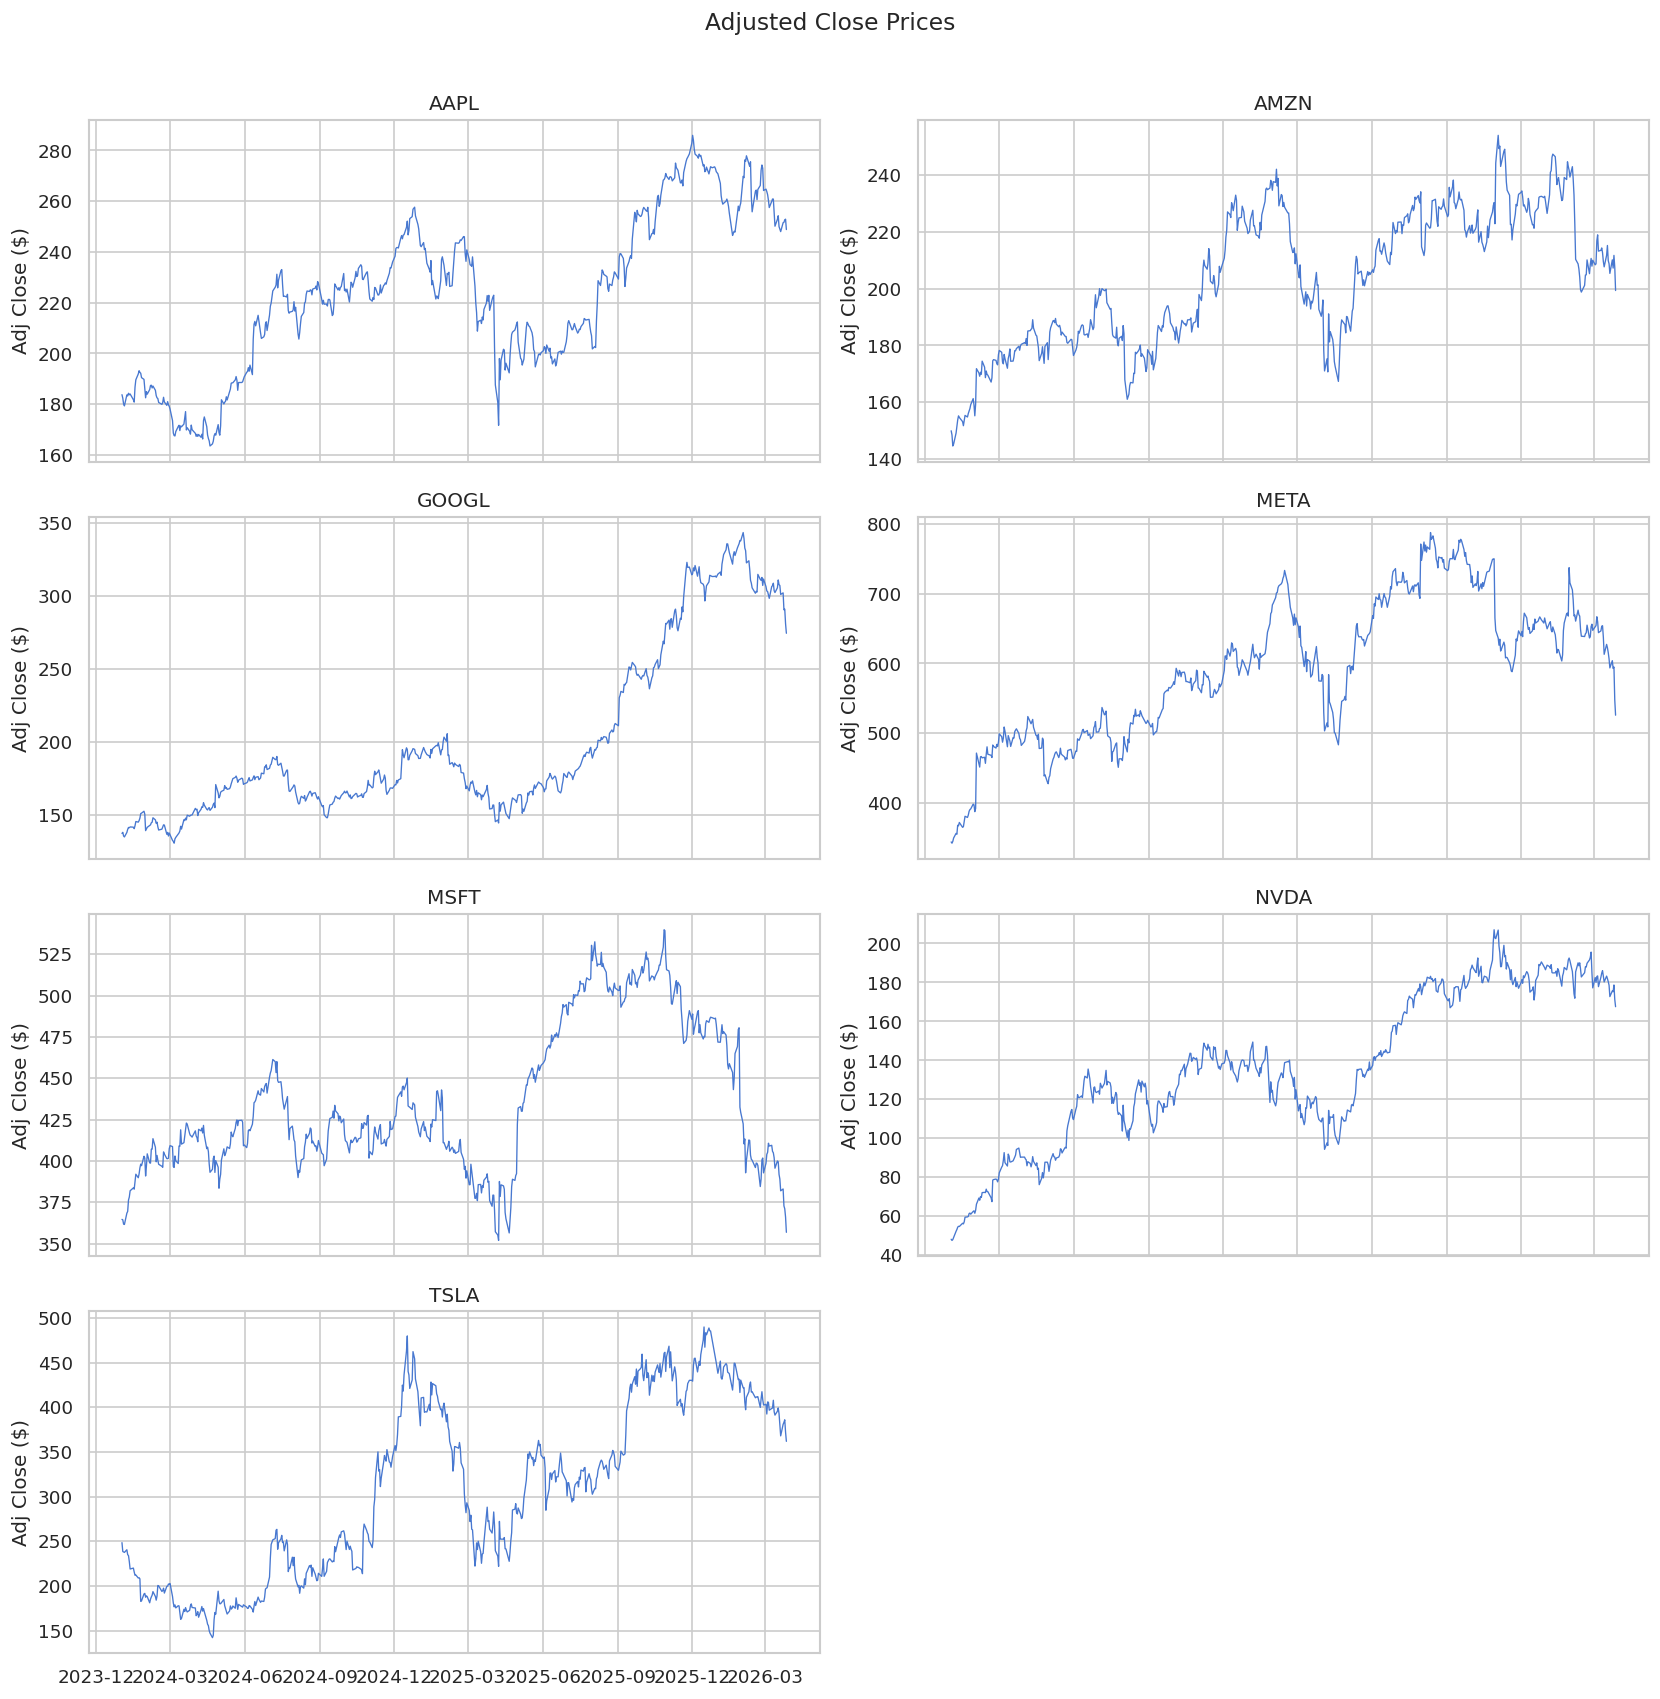

In [111]:
# Individual Adjusted Close price charts per ticker (subplots).
# Visual check for data gaps, suspicious flat periods, or price anomalies.
tickers = sorted(prices["Ticker"].unique())
n_tickers = len(tickers)
ncols = 2
nrows = (n_tickers + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), sharex=True)
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    subset = prices[prices["Ticker"] == ticker]
    ax.plot(subset["Date"], subset["Adj Close"], linewidth=0.8)
    ax.set_title(ticker)
    ax.set_ylabel("Adj Close ($)")
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Hide unused subplot axes (when ticker count is odd)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Adjusted Close Prices", fontsize=14, y=1.01)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

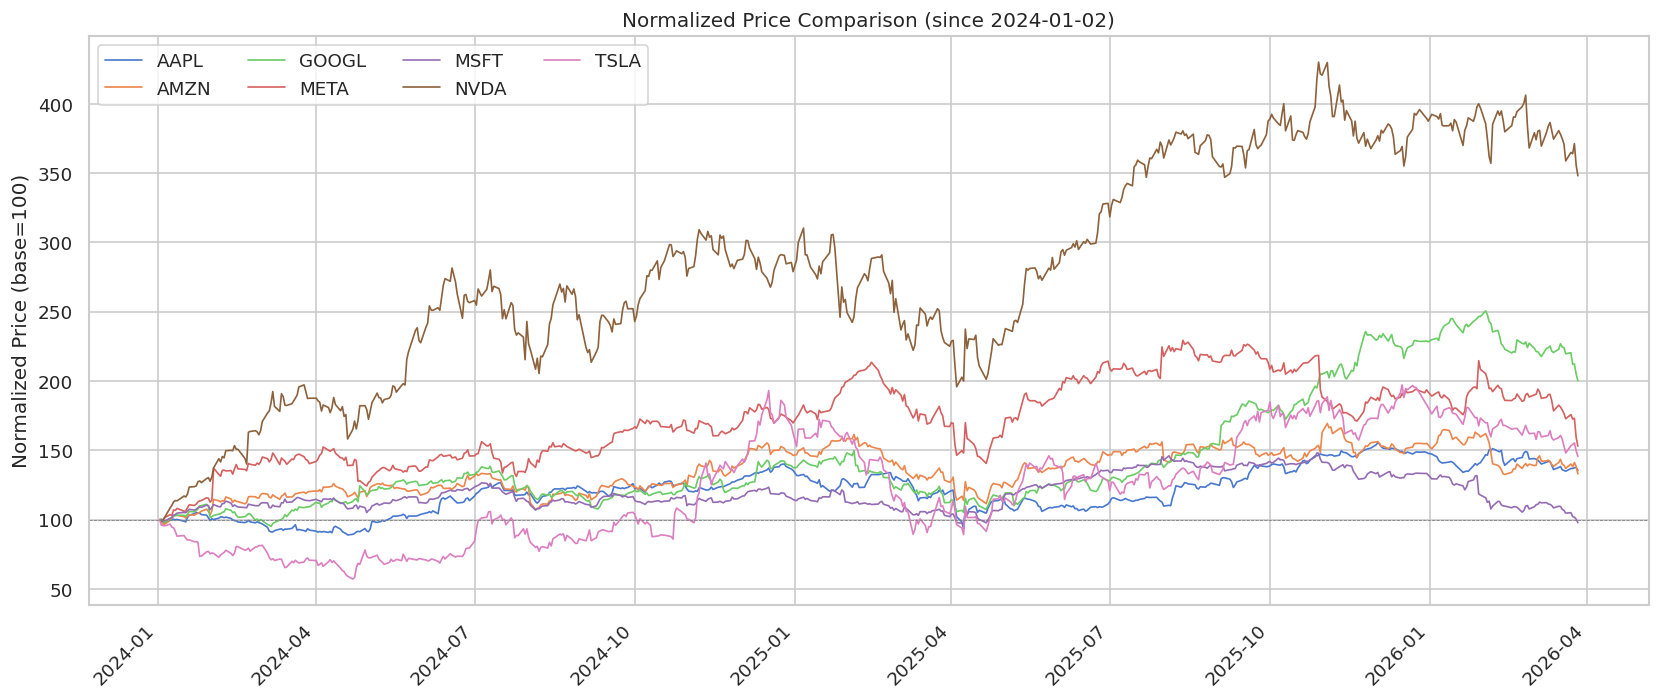

In [112]:
# Normalized price comparison: all tickers on the same scale (base = 100).
# Makes it easy to compare relative performance regardless of absolute price level.
fig, ax = plt.subplots(figsize=(14, 6))

for ticker in tickers:
    subset = prices[prices["Ticker"] == ticker].sort_values("Date")
    base = subset["Adj Close"].iloc[0]  # First day's price = 100
    ax.plot(subset["Date"], subset["Adj Close"] / base * 100, label=ticker, linewidth=1)

ax.axhline(100, color="grey", linewidth=0.5, linestyle="--")
ax.set_ylabel("Normalized Price (base=100)")
ax.set_title("Normalized Price Comparison (since 2024-01-02)")
ax.legend(loc="upper left", ncol=4)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7 — Tweet Volume & Timing

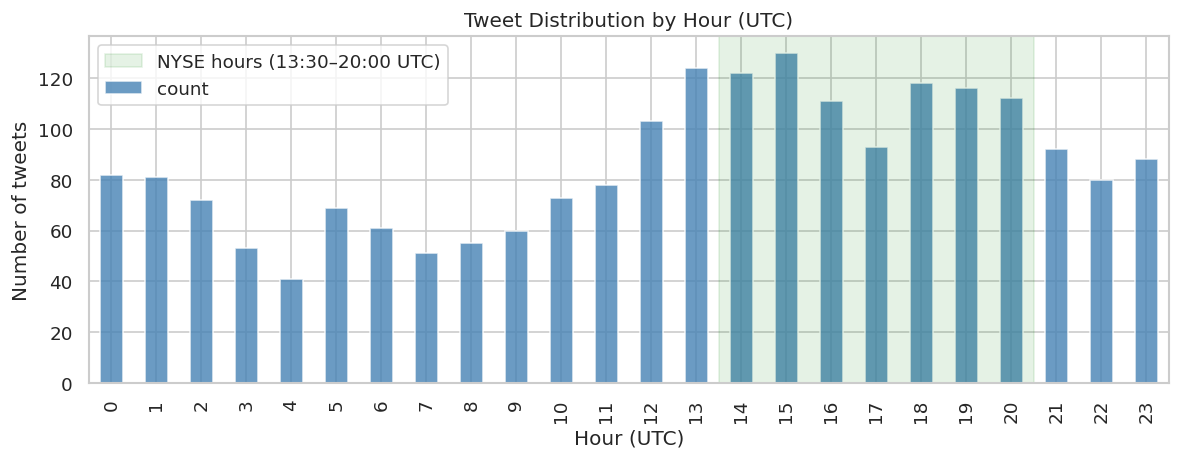

In [113]:
# Hourly distribution of tweets (UTC). Highlights when most tweets are posted.
# Green band marks NYSE regular trading hours (13:30–20:00 UTC / 9:30–16:00 ET).
tweets["hour"] = tweets["posted_at"].dt.hour

fig, ax = plt.subplots(figsize=(10, 4))
tweets["hour"].value_counts().sort_index().plot.bar(ax=ax, color="steelblue", alpha=0.8)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Number of tweets")
ax.set_title("Tweet Distribution by Hour (UTC)")
ax.axvspan(13.5, 20.5, alpha=0.1, color="green", label="NYSE hours (13:30–20:00 UTC)")
ax.legend()
plt.tight_layout()
plt.show()

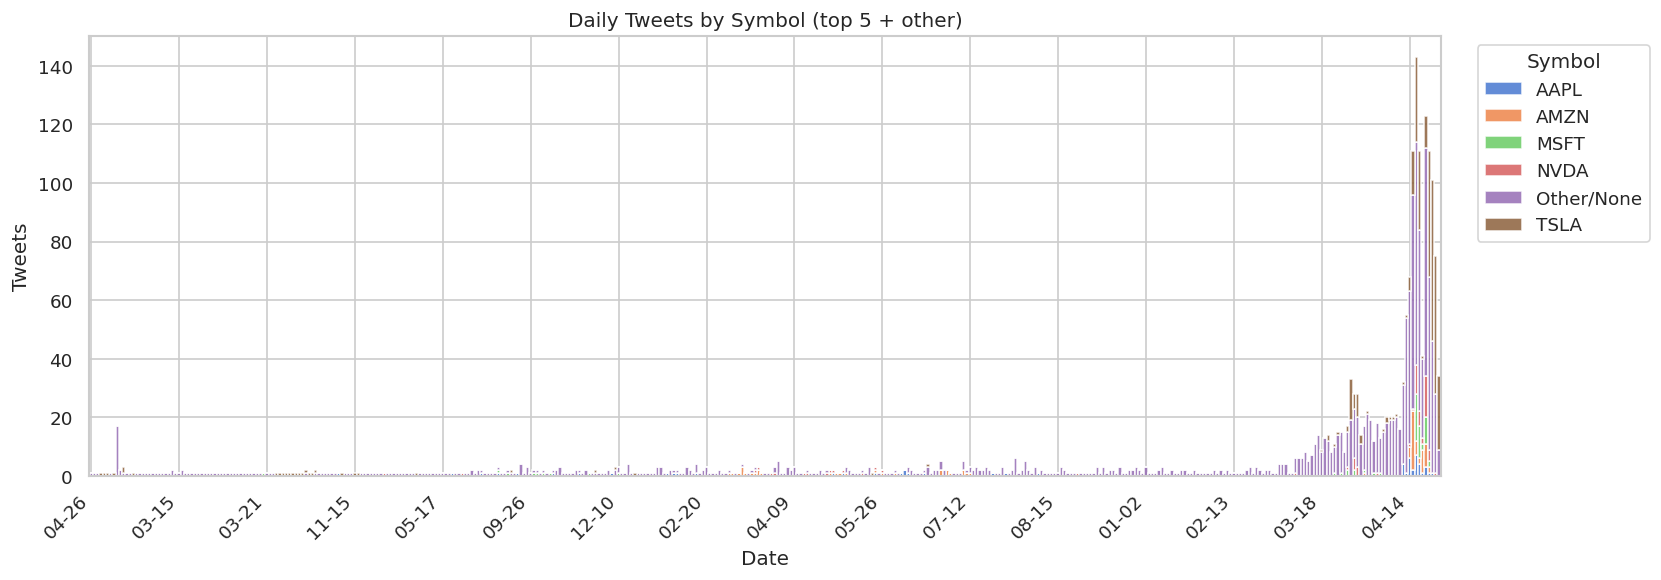

In [114]:
# Stacked bar chart: daily tweet volume broken down by the top 5 symbols.
# "Other/None" groups all remaining symbols and tweets without a cashtag.
top5 = tweets["symbol"].value_counts().head(5).index.tolist()
tweets["symbol_group"] = tweets["symbol"].where(tweets["symbol"].isin(top5), other="Other/None")
tweets["date_dt"] = pd.to_datetime(tweets["date"])

daily_symbol = (
    tweets.groupby(["date_dt", "symbol_group"]).size().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 5))
daily_symbol.plot.bar(stacked=True, ax=ax, width=1, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("Tweets")
ax.set_title("Daily Tweets by Symbol (top 5 + other)")
# Reduce x-tick clutter: show only every Nth label
n_ticks = len(daily_symbol)
step = max(1, n_ticks // 15)
ax.set_xticks(range(0, n_ticks, step))
ax.set_xticklabels(
    [d.strftime("%m-%d") for d in daily_symbol.index[::step]], rotation=45, ha="right"
)
ax.legend(title="Symbol", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8 — Tweet–Price Overlay (Top Tickers)

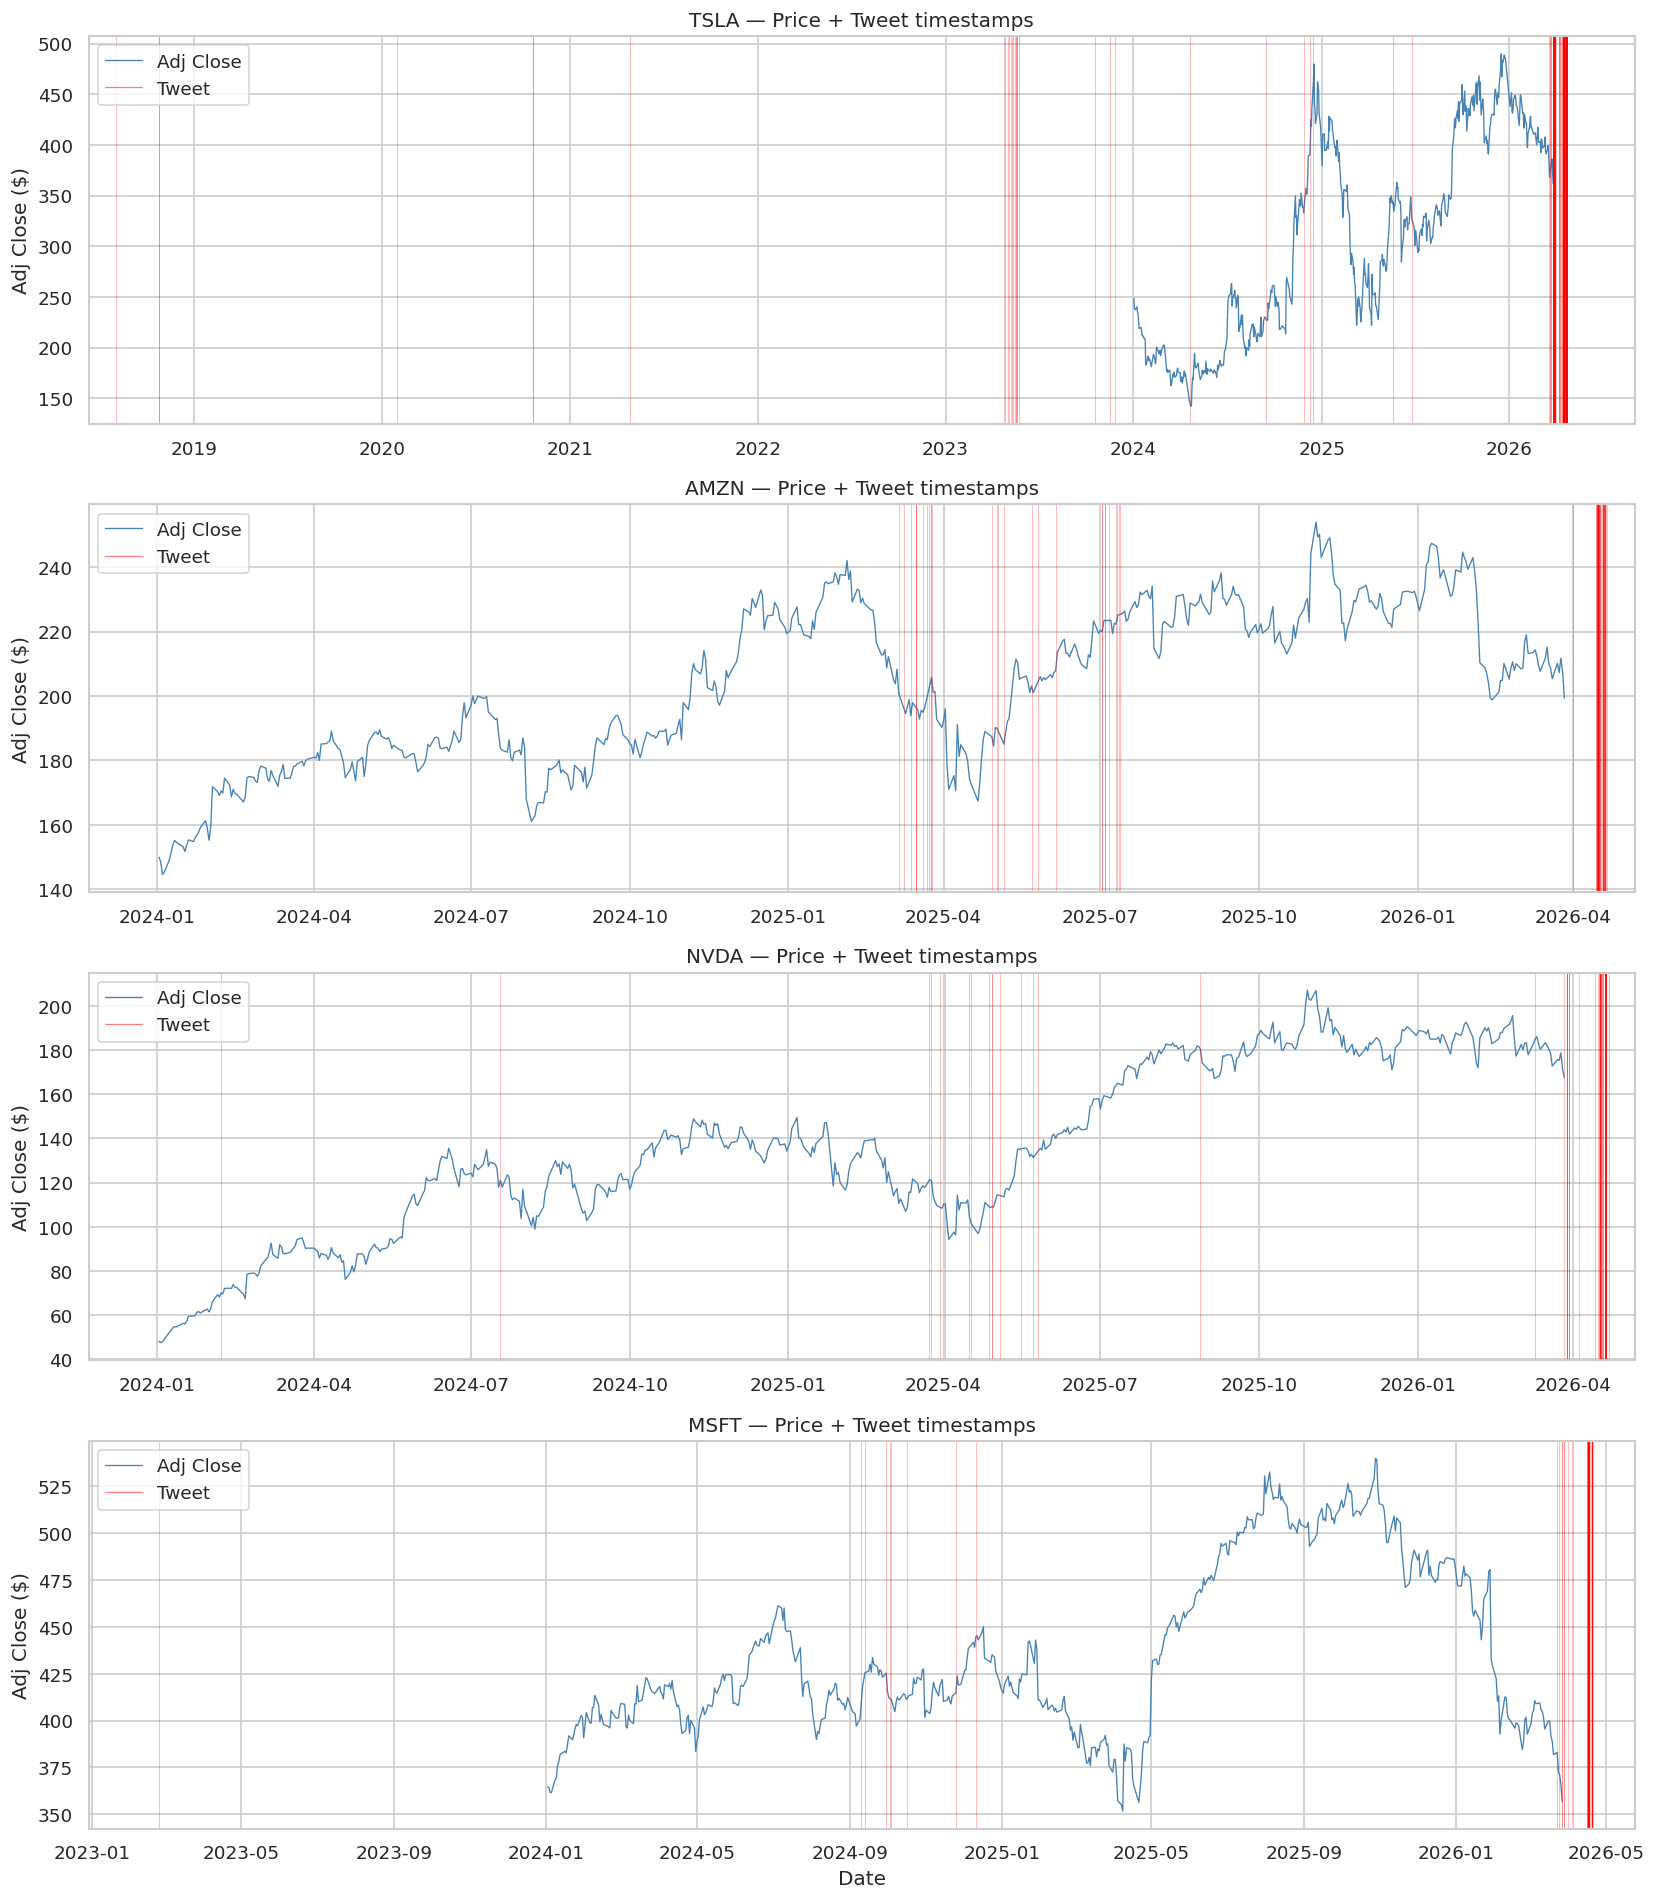

In [115]:
# Overlay plot: daily Adj Close price line + red vertical lines for each tweet.
# Shows when tweets cluster relative to price movements.
# Limited to top 4 tickers that appear in both tweet and price datasets.
from matplotlib.lines import Line2D

csv_tickers = set(prices["Ticker"].unique())
overlay_tickers = [t for t in top5 if t in csv_tickers][:4]

fig, axes = plt.subplots(len(overlay_tickers), 1, figsize=(14, 4 * len(overlay_tickers)), sharex=False)
if len(overlay_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, overlay_tickers):
    # Plot the daily price line
    p = prices[prices["Ticker"] == ticker].sort_values("Date")
    ax.plot(p["Date"], p["Adj Close"], color="steelblue", linewidth=0.8, label="Adj Close")

    # Add a vertical line for each tweet timestamp
    tw = tweets[tweets["symbol"] == ticker]
    for _, row in tw.iterrows():
        ax.axvline(row["posted_at"], color="red", alpha=0.3, linewidth=0.5)

    ax.set_title(f"{ticker} — Price + Tweet timestamps")
    ax.set_ylabel("Adj Close ($)")
    # Custom legend entry for tweets (Line2D avoids pd.NaT crash)
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([0], [0], color="red", alpha=0.5, linewidth=0.8))
    labels.append("Tweet")
    ax.legend(handles=handles, labels=labels, loc="upper left")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 9 — Follower & Engagement Analysis

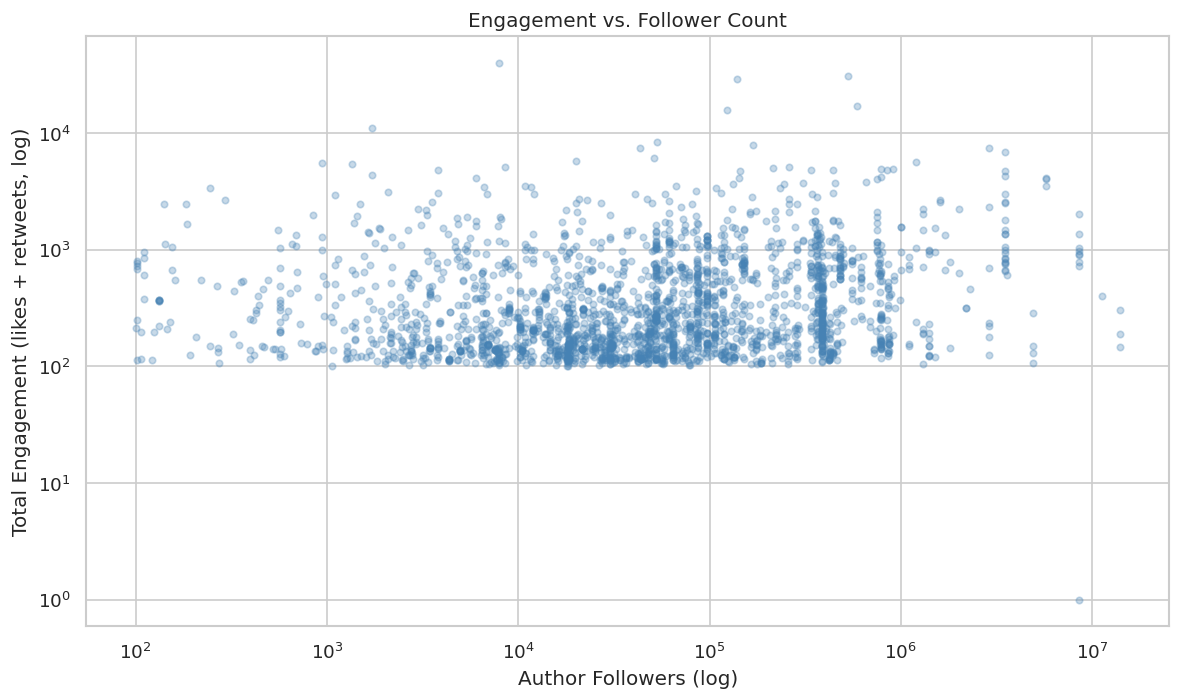

In [116]:
# Scatter plot: author follower count vs. total engagement (log-log scale).
# Tests whether high-follower authors actually generate more engagement.
# Log scale because both distributions are heavily right-skewed.
merged["total_engagement"] = merged["likes"].fillna(0) + merged["retweets"].fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    merged["author_followers"].clip(lower=1),
    merged["total_engagement"].clip(lower=1),
    alpha=0.3, s=15, c="steelblue"
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Author Followers (log)")
ax.set_ylabel("Total Engagement (likes + retweets, log)")
ax.set_title("Engagement vs. Follower Count")
plt.tight_layout()
plt.show()

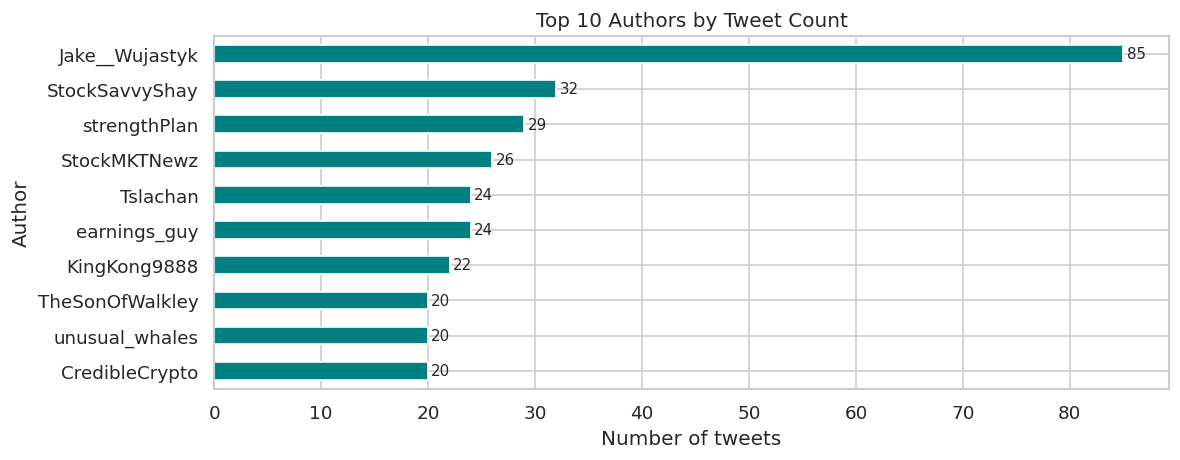

In [117]:
# Top 10 most prolific authors by tweet count.
# High-volume authors may be bots or financial influencers — worth investigating.
top_authors = tweets["author"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
top_authors.plot.barh(ax=ax, color="teal")
ax.set_xlabel("Number of tweets")
ax.set_ylabel("Author")
ax.set_title("Top 10 Authors by Tweet Count")
ax.invert_yaxis()
for i, v in enumerate(top_authors.values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 10 — Summary & Recommendations

In [118]:
# Auto-generate a summary table with all key metrics from previous sections.
# This provides a single consolidated view for the project report.
from IPython.display import Markdown, display

date_min = tweets["posted_at"].min()
date_max = tweets["posted_at"].max()

# Detect days with zero tweets (collection gaps)
all_days = pd.date_range(date_min.normalize(), date_max.normalize(), freq="D")
active_days = set(tweets["posted_at"].dt.normalize())
gap_days = sorted(set(all_days) - active_days)

# Find the longest consecutive gap (streak of days with no tweets)
if gap_days:
    gap_series = pd.Series(gap_days)
    gap_groups = (gap_series.diff().dt.days != 1).cumsum()
    longest_gap = gap_series.groupby(gap_groups).agg(["first", "last", "count"]).sort_values("count", ascending=False).iloc[0]
    gap_str = f"{longest_gap['first']:%Y-%m-%d} → {longest_gap['last']:%Y-%m-%d} ({int(longest_gap['count'])} days)"
else:
    gap_str = "None"

# Collect metrics computed in earlier sections
n_dup_content = tweets['content'].duplicated().sum()
n_empty = tweets['content'].isna().sum() + (tweets['content'].str.strip() == '').sum()
en_share = (tweets['lang'] == 'en').mean() if 'lang' in tweets.columns else float('nan')
n_outlier_returns = int(prices_sorted['is_outlier'].sum()) if 'is_outlier' in prices_sorted.columns else 0
n_td = int(tweets['is_trading_day'].sum()) if 'is_trading_day' in tweets.columns else 0
n_ntd = int((~tweets['is_trading_day']).sum()) if 'is_trading_day' in tweets.columns else 0
n_viral = int((merged['total_engagement'] >= merged['total_engagement'].quantile(0.95)).sum()) if 'total_engagement' in merged.columns else 0

# Render the summary as a Markdown table
summary = f"""
### Key Findings

| Metric | Value |
|--------|-------|
| Total tweets collected | {len(tweets):,} |
| Tweets with cashtag | {n_with_symbol:,} ({n_with_symbol/n_total:.1%}) |
| Unique symbols | {tweets['symbol'].nunique()} |
| Tweets with price snapshots | {n_with_prices:,} ({n_with_prices/len(tweets):.1%}) |
| Duplicate content tweets | {n_dup_content} |
| Empty / NaN content | {n_empty} |
| English tweet share | {en_share:.1%} |
| Viral tweets (≥P95 engagement) | {n_viral} |
| Tweets on trading days | {n_td} ({n_td/len(tweets):.1%}) |
| Tweets on non-trading days | {n_ntd} ({n_ntd/len(tweets):.1%}) |
| Tweet date range | {date_min:%Y-%m-%d} → {date_max:%Y-%m-%d} |
| Days with zero tweets | {len(gap_days)} |
| Longest gap | {gap_str} |
| Historical price tickers | {len(prices['Ticker'].unique())} |
| Price rows (CSV) | {len(prices):,} |
| Outlier returns (IQR×3) | {n_outlier_returns} |

### Recommendations

1. **Address the tweet gap**: The longest gap ({gap_str}) likely corresponds to the X bot-detection / session-expiry issue.
   Consider re-crawling or marking this period as missing in downstream analysis.
2. **Filter non-stock symbols**: Symbols like BTC, QUBIC, AKT are not equities — exclude them for stock-focused sentiment analysis.
3. **Focus analysis on top tickers**: The vast majority of tweets reference TSLA, AMZN, AAPL, NVDA, GOOGL.
   Sufficient volume exists only for these tickers.
4. **Handle after-hours tweets**: Many tweets fall outside NYSE trading hours, resulting in missing price snapshots.
   Decide whether to map to next-open or exclude.
5. **Next step → Sentiment labeling**: Run sentiment models on tweet content and align with price movements.
"""

display(Markdown(summary))


### Key Findings

| Metric | Value |
|--------|-------|
| Total tweets collected | 2,065 |
| Tweets with cashtag | 965 (46.7%) |
| Unique symbols | 101 |
| Tweets with price snapshots | 244 (11.8%) |
| Duplicate content tweets | 8 |
| Empty / NaN content | 0 |
| English tweet share | 95.6% |
| Viral tweets (≥P95 engagement) | 119 |
| Tweets on trading days | 522 (25.3%) |
| Tweets on non-trading days | 1543 (74.7%) |
| Tweet date range | 2016-04-26 → 2026-04-23 |
| Days with zero tweets | 3235 |
| Longest gap | 2016-05-14 → 2018-06-02 (750 days) |
| Historical price tickers | 7 |
| Price rows (CSV) | 3,927 |
| Outlier returns (IQR×3) | 38 |

### Recommendations

1. **Address the tweet gap**: The longest gap (2016-05-14 → 2018-06-02 (750 days)) likely corresponds to the X bot-detection / session-expiry issue.
   Consider re-crawling or marking this period as missing in downstream analysis.
2. **Filter non-stock symbols**: Symbols like BTC, QUBIC, AKT are not equities — exclude them for stock-focused sentiment analysis.
3. **Focus analysis on top tickers**: The vast majority of tweets reference TSLA, AMZN, AAPL, NVDA, GOOGL.
   Sufficient volume exists only for these tickers.
4. **Handle after-hours tweets**: Many tweets fall outside NYSE trading hours, resulting in missing price snapshots.
   Decide whether to map to next-open or exclude.
5. **Next step → Sentiment labeling**: Run sentiment models on tweet content and align with price movements.


## 11 — Virality Score & Engagement Velocity

Tweets are tracked every 15 minutes for 2 hours after discovery (`tweet_snapshots`).
This section computes:

- **Absolute engagement** at first snapshot (likes + retweets) — always available
- **Engagement velocity** (Δlikes / Δt in minutes) between first and last snapshot — requires ≥ 2 snapshots
- **Viral flag** — top-5 % by velocity (or by absolute engagement when only 1 snapshot exists)

> **Note:** If every tweet has only 1 snapshot (crawler not yet run for a full poll cycle),
> velocity falls back to `NaN` and the viral flag is based on absolute engagement only.

In [119]:
# ---------------------------------------------------------------------------
# Step 1: Build per-tweet engagement summary from tweet_snapshots.
# For each tweet we take:
#   - first_snap_likes / first_snap_retweets  → engagement at discovery
#   - last_snap_likes  / last_snap_retweets   → final tracked engagement
#   - snap_count                              → how many snapshots exist
#   - velocity_likes_per_min                  → Δlikes / Δt (NaN if only 1 snapshot)
# ---------------------------------------------------------------------------

snaps = snapshots.copy()
snaps["crawled_at"] = pd.to_datetime(snaps["crawled_at"], utc=True)

# First and last snapshot per tweet
first_snaps = (
    snaps.sort_values("crawled_at")
    .groupby("tweet_id")
    .first()
    .rename(columns={"likes": "first_likes", "retweets": "first_retweets", "crawled_at": "first_crawled_at"})
    .reset_index()
)
last_snaps = (
    snaps.sort_values("crawled_at")
    .groupby("tweet_id")
    .last()
    .rename(columns={"likes": "last_likes", "retweets": "last_retweets", "crawled_at": "last_crawled_at"})
    .reset_index()
)
snap_counts = snaps.groupby("tweet_id").size().rename("snap_count").reset_index()

engagement = (
    first_snaps
    .merge(last_snaps, on="tweet_id")
    .merge(snap_counts, on="tweet_id")
)

# Engagement velocity: Δlikes / elapsed minutes between first and last snapshot
engagement["elapsed_min"] = (
    (engagement["last_crawled_at"] - engagement["first_crawled_at"])
    .dt.total_seconds() / 60
)
engagement["velocity_likes_per_min"] = (
    (engagement["last_likes"] - engagement["first_likes"]) / engagement["elapsed_min"]
)
# elapsed_min == 0 → only 1 snapshot → velocity is undefined
engagement.loc[engagement["elapsed_min"] == 0, "velocity_likes_per_min"] = float("nan")

# Absolute engagement at first snapshot
engagement["total_engagement_first"] = engagement["first_likes"] + engagement["first_retweets"]

# Viral flag: top-5 % by velocity; fall back to absolute engagement when velocity is unavailable
if engagement["velocity_likes_per_min"].notna().any():
    vel_p95 = engagement["velocity_likes_per_min"].quantile(0.95)
    engagement["is_viral"] = engagement["velocity_likes_per_min"] >= vel_p95
    viral_metric = "velocity_likes_per_min"
    viral_label = "Likes / minute (velocity)"
else:
    eng_p95 = engagement["total_engagement_first"].quantile(0.95)
    engagement["is_viral"] = engagement["total_engagement_first"] >= eng_p95
    viral_metric = "total_engagement_first"
    viral_label = "Total engagement at first snapshot (fallback — no multi-snapshot data yet)"

n_viral = engagement["is_viral"].sum()
pct_viral = n_viral / len(engagement)

print(f"Tweets analysed:        {len(engagement):>6,}")
print(f"Tweets with >1 snapshot:{(engagement['snap_count'] > 1).sum():>6,}")
print(f"Viral metric used:      {viral_metric}")
print(f"Viral tweets (top 5%):  {n_viral:>6,}  ({pct_viral:.1%})")
print()
print(engagement[["tweet_id", "first_likes", "last_likes", "snap_count",
                   "velocity_likes_per_min", "total_engagement_first", "is_viral"]]
      .sort_values(viral_metric, ascending=False)
      .head(10)
      .to_string(index=False))

Tweets analysed:         2,065
Tweets with >1 snapshot:   102
Viral metric used:      velocity_likes_per_min
Viral tweets (top 5%):       6  (0.3%)

           tweet_id  first_likes  last_likes  snap_count  velocity_likes_per_min  total_engagement_first  is_viral
2047194112252944869          297         514           5                2.226886                     365      True
2046595770837819606          303         766           2                1.804107                     335      True
2047174502770205001          205         608           5                1.675368                     225      True
2047248662296686594          136         314           5                1.424800                     142      True
2046568167770861923          239         806           2                1.302008                     275      True
2046581216653037582          920        1200           2                1.094555                    1010      True
2046595469820776836          581         835  

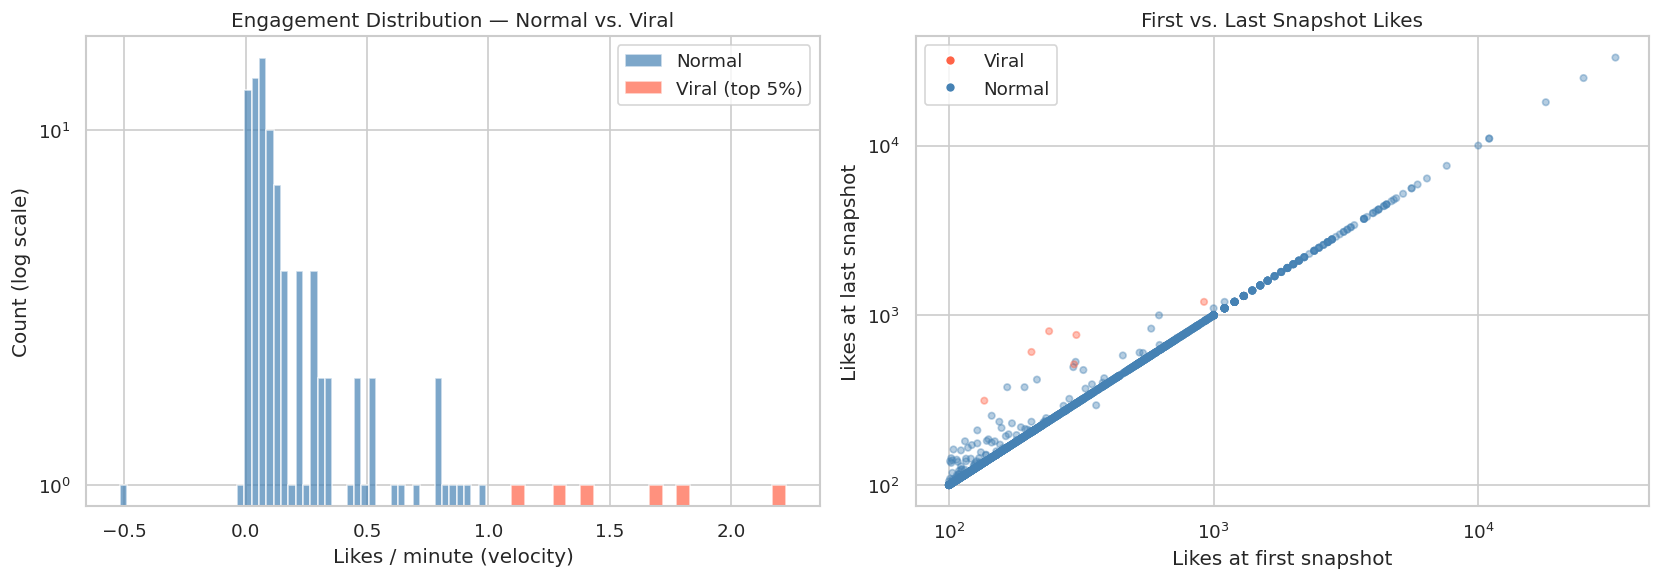

In [120]:
# ---------------------------------------------------------------------------
# Step 2: Visualise engagement distribution — normal vs. viral tweets
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of the primary viral metric
ax = axes[0]
normal = engagement.loc[~engagement["is_viral"], viral_metric].dropna()
viral  = engagement.loc[ engagement["is_viral"],  viral_metric].dropna()
ax.hist(normal, bins=50, alpha=0.7, label="Normal", color="steelblue", log=True)
ax.hist(viral,  bins=20, alpha=0.7, label="Viral (top 5%)", color="tomato", log=True)
ax.set_xlabel(viral_label)
ax.set_ylabel("Count (log scale)")
ax.set_title("Engagement Distribution — Normal vs. Viral")
ax.legend()

# Right: scatter — first_likes vs. last_likes coloured by viral flag
ax2 = axes[1]
scatter = ax2.scatter(
    engagement["first_likes"],
    engagement["last_likes"],
    c=engagement["is_viral"].map({True: "tomato", False: "steelblue"}),
    alpha=0.4, s=15,
)
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("Likes at first snapshot")
ax2.set_ylabel("Likes at last snapshot")
ax2.set_title("First vs. Last Snapshot Likes")
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tomato",    label="Viral"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", label="Normal"),
]
ax2.legend(handles=handles)

plt.tight_layout()
plt.show()

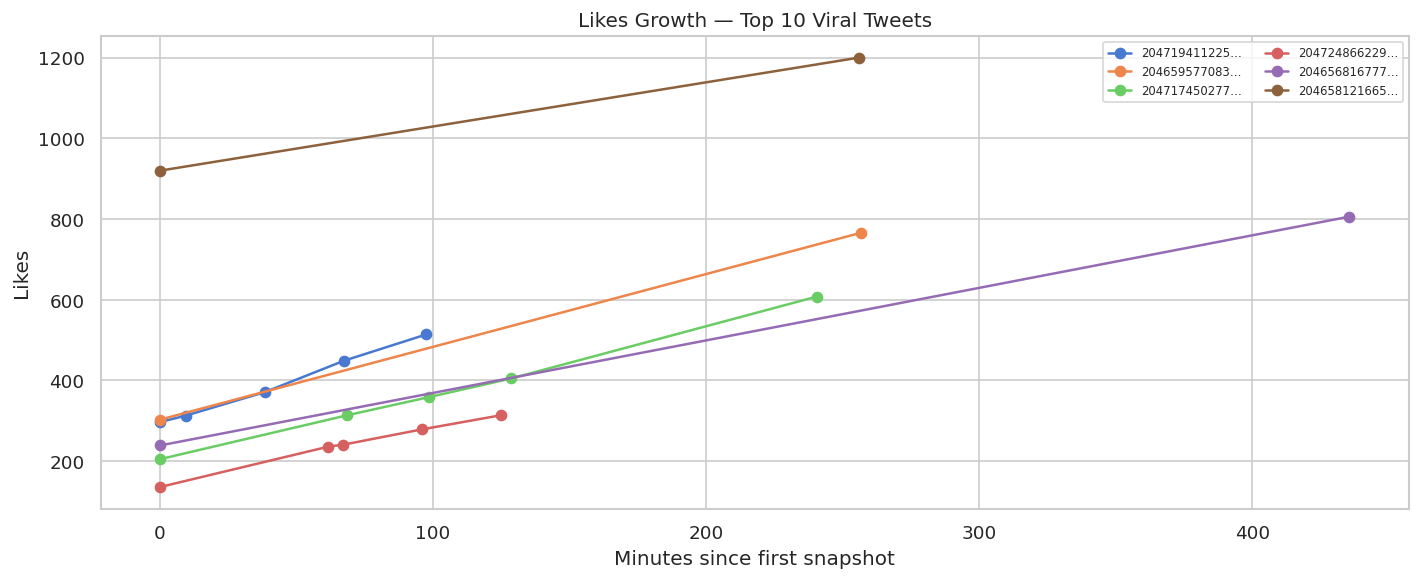

In [121]:
# ---------------------------------------------------------------------------
# Step 3: Velocity timeline (only meaningful when multi-snapshot data exists)
# Shows the engagement growth curve for the top-10 most viral tweets.
# ---------------------------------------------------------------------------

top_viral_ids = (
    engagement[engagement["is_viral"]]
    .nlargest(10, viral_metric)["tweet_id"]
    .tolist()
)

if engagement["snap_count"].max() > 1:
    fig, ax = plt.subplots(figsize=(12, 5))
    for tid in top_viral_ids:
        ts = snaps[snaps["tweet_id"] == tid].sort_values("crawled_at")
        t0 = ts["crawled_at"].iloc[0]
        ts = ts.assign(minutes_since_post=(ts["crawled_at"] - t0).dt.total_seconds() / 60)
        ax.plot(ts["minutes_since_post"], ts["likes"], marker="o", linewidth=1.5,
                label=tid[:12] + "…")
    ax.set_xlabel("Minutes since first snapshot")
    ax.set_ylabel("Likes")
    ax.set_title("Likes Growth — Top 10 Viral Tweets")
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()
else:
    print("No multi-snapshot data available yet — velocity timeline will appear once")
    print("the crawler has been running for at least one full 2-hour poll cycle.")
    print()
    print("Top 10 tweets by absolute engagement (first snapshot):")
    print(
        engagement.nlargest(10, "total_engagement_first")
        [["tweet_id", "first_likes", "first_retweets", "total_engagement_first"]]
        .to_string(index=False)
    )